In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score,classification_report, f1_score, ConfusionMatrixDisplay
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
import seaborn as sns
from collections import Counter
import re
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import copy

In [44]:
df = pd.read_json(r"resources/emoset_challenge_1000_augmented.json")

# unpacking the annotations dictionary and merging back into the main data frame
annotations_df = df['annotations'].apply(pd.Series)
df = pd.concat([df, annotations_df], axis=1) #

display(df.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   image_name                 1000 non-null   object 
 1   annotations                1000 non-null   object 
 2   description                1000 non-null   object 
 3   embedding                  1000 non-null   object 
 4   viewer_feelings            1000 non-null   object 
 5   description_embedding      1000 non-null   object 
 6   viewer_feelings_embedding  1000 non-null   object 
 7   image_id                   1000 non-null   object 
 8   emotion                    1000 non-null   object 
 9   brightness                 999 non-null    float64
 10  colorfulness               976 non-null    float64
 11  facial_expression          112 non-null    object 
 12  object                     513 non-null    object 
 13  human_action               114 non-null    object

None

In [45]:
# First - get a sense of distribution of labels
LABEL_COLUMN = 'emotion'
LABELS = df[LABEL_COLUMN].unique()

display(f'Number of emotion classes {len(LABELS)}')

display('Count of samples per emotion:')
emotion_counts = df[LABEL_COLUMN].value_counts()
display(emotion_counts)

'Number of emotion classes 8'

'Count of samples per emotion:'

emotion
anger          125
excitement     125
disgust        125
amusement      125
awe            125
contentment    125
sadness        125
fear           125
Name: count, dtype: int64

In [46]:
# Handle Missing Data
nan_columns = df.columns[df.isnull().any()]
nan_data = df[nan_columns]

# Calculate fractions of null values.
nan_counts = nan_data.isnull().sum()
fraction_missing = nan_counts / len(nan_data)
all_missing = {'Total Missing': round(fraction_missing * 100, 2)}
for emotion in LABELS:
    nan_counts_for_emotion = nan_data[df[LABEL_COLUMN] == emotion].isnull().sum()
    fraction_missing_for_emotion = round(nan_counts_for_emotion / nan_counts * 100, 2)
    all_missing[emotion] = fraction_missing_for_emotion

display(f'Desired ratio of missing data per emotion: {round(100/len(LABELS), 2)}%')
display(pd.DataFrame(all_missing).sort_values("Total Missing", ascending=False))

'Desired ratio of missing data per emotion: 12.5%'

,Total Missing,anger,excitement,disgust,amusement,awe,contentment,sadness,fear
facial_expression,88.8,12.61,10.02,13.96,12.16,13.51,11.26,12.61,13.85
human_action,88.6,12.75,8.24,13.88,12.64,13.43,12.42,13.09,13.54
scene,78.8,14.72,9.26,13.58,13.32,9.52,13.71,11.29,14.59
object,48.7,13.55,6.78,15.81,13.55,12.53,10.27,10.27,17.25
colorfulness,2.4,41.67,0.00,4.17,4.17,8.33,0.00,16.67,25.00
brightness,0.1,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00


In [47]:
# brightness and colorfulness have a low % missing, so drop rows with missing values
## Note - colorfulness seems to have missing not at random, but the size of the missing is so small that it is not worth it to impute
df = df.dropna(subset=['brightness', 'colorfulness'])
display(f'After dropping rows with missing brightness or colorfulness there are: {df.shape[0]} rows left')

'After dropping rows with missing brightness or colorfulness there are: 976 rows left'

In [48]:
# The remaining columns have a large percent missing - but something missing is indicative of whats in the picture not bad data
## So add a "None" category to these columns
for col in ['facial_expression', 'human_action', 'scene']:
    df[col] = df[col].fillna('None')

## for object - since its a list, add an empty list when null
df['object'] = df['object'].apply(lambda x: x if isinstance(x, list) else [])
df['has_object'] = df['object'].apply(lambda x: len(x) > 0)

In [49]:
# Define the columns we want to examine by type
IDENTIFIER_COLUMNS = ['image_id', 'image_name']
NUMERIC_METADATA = ['brightness', 'colorfulness']
CATEGORICAL_METADATA = ['facial_expression', 'human_action', 'scene', 'has_object']
MULTILABLE_METADATA = ['object']
TEXT_COLUMNS = ['description', 'viewer_feelings']
EMBEDDING_COLUMNS = [
    'embedding',
    'viewer_feelings_embedding',
    'description_embedding'
]

In [50]:
# Check the identifier columns

# First see if there are any duplicates
for col in IDENTIFIER_COLUMNS:
    display(f'Number of duplicate values for column {col}: {df[col].duplicated().sum()}') # checking image names looking for bias

# Next check if the identifiers leak any data about the label 
display(df[IDENTIFIER_COLUMNS].head()) # -> they have the label in them! so do not use the identifiers in the model

'Number of duplicate values for column image_id: 0'

'Number of duplicate values for column image_name: 0'

,image_id,image_name
0,anger_05461,anger_05461.jpg
1,anger_04009,anger_04009.jpg
2,excitement_14481,excitement_14481.jpg
3,disgust_09637,disgust_09637.jpg
4,amusement_13130,amusement_13130.jpg


,brightness,colorfulness
count,976.000000,976.000000
mean,0.486885,0.493545
std,0.149639,0.195302
min,0.000000,0.000000
25%,0.400000,0.400000
50%,0.500000,0.500000
75%,0.600000,0.600000
max,0.900000,1.000000


,brightness,colorfulness
emotion,,
amusement,0.537903,0.627419
anger,0.460870,0.481739
awe,0.535772,0.524390
contentment,0.548000,0.504000
disgust,0.464516,0.441935
excitement,0.520800,0.584800
fear,0.378992,0.417647
sadness,0.440496,0.358678


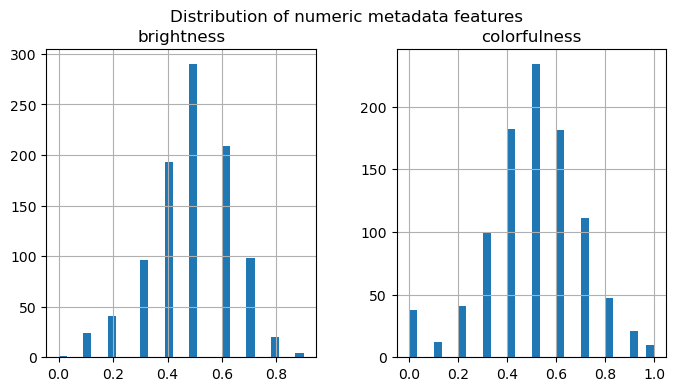

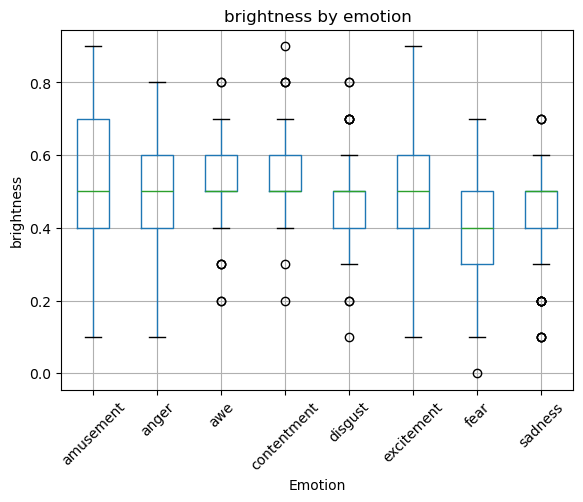

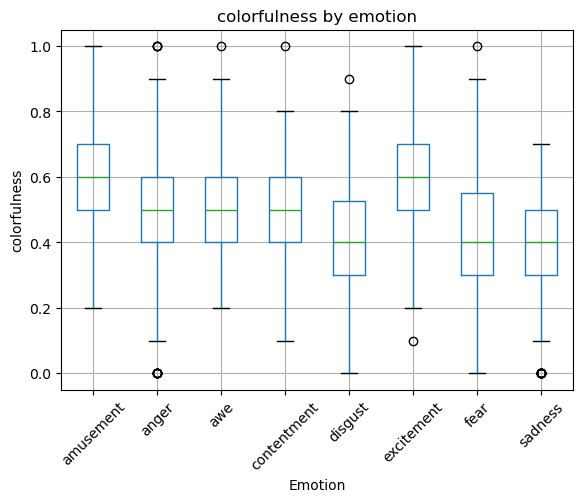

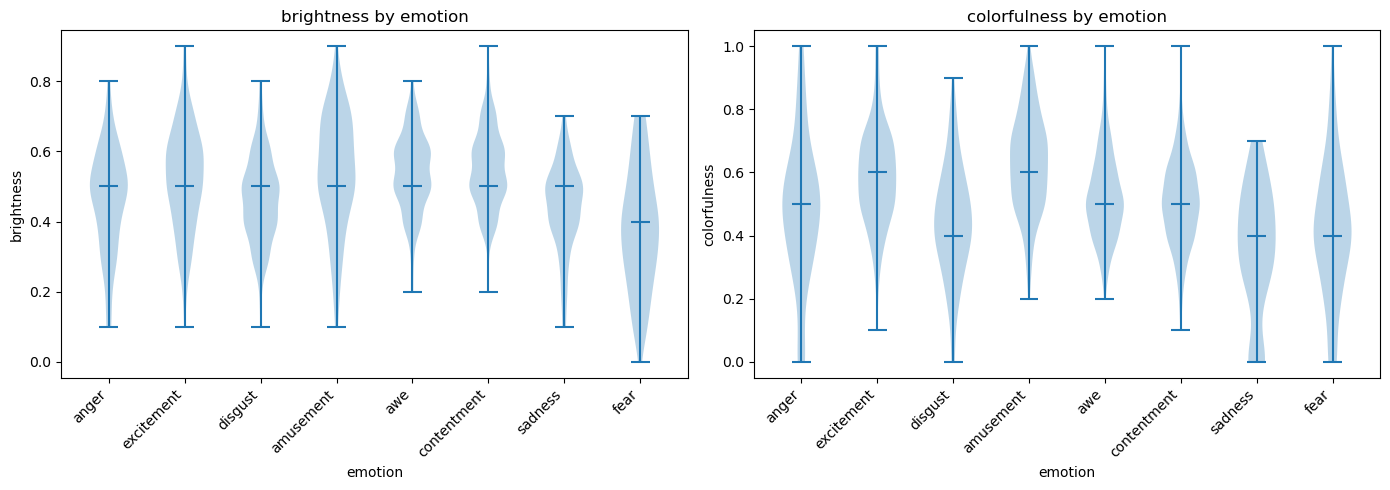

'OVERALL CORRELATIONS'

              brightness  colorfulness
brightness      1.000000      0.236798
colorfulness    0.236798      1.000000


'CORRELATION BETWEEN BRIGHTNESS AND COLORFULNESS BY EMOTION'

emotion
amusement      0.138477
anger          0.159274
awe           -0.019741
contentment    0.091221
disgust        0.339841
excitement     0.073280
fear           0.043500
sadness        0.278730
Name: brightness, dtype: float64

In [51]:
# 4.1 Distribution of numeric
display(df[NUMERIC_METADATA].describe())
display(df.groupby(LABEL_COLUMN)[NUMERIC_METADATA].mean())

df[NUMERIC_METADATA].hist(bins=30, figsize=(8, 4))
plt.suptitle("Distribution of numeric metadata features")
plt.show()
# Box and Violin plots
for feature in NUMERIC_METADATA:
    df.boxplot(column=feature, by='emotion')
    plt.title(f"{feature} by emotion")
    plt.suptitle("")  # removes automatic title
    plt.xlabel("Emotion")
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, NUMERIC_METADATA):
    ax.violinplot(
        [df[df[LABEL_COLUMN] == e][feature].values for e in LABELS],
        positions=range(len(LABELS)),
        showmedians=True
    )
    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=45, ha='right')
    ax.set_title(f'{feature} by {LABEL_COLUMN}')
    ax.set_xlabel(f'{LABEL_COLUMN}')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## takeaway - both scaled from 0 to 1, centered around 0.5, so no need to normalize

# Correlation
display("OVERALL CORRELATIONS")
print(df[NUMERIC_METADATA].corr())
display("CORRELATION BETWEEN BRIGHTNESS AND COLORFULNESS BY EMOTION")
df.groupby(LABEL_COLUMN)[['brightness', 'colorfulness']].corr().unstack()['colorfulness']['brightness']

## takeaway - correlation is low, so we can use both features in the model

'\n--- Facial Expression DISTRIBUTION ---'

'Total unique categories: 6'

'Categories appearing >= 10 times: 4'

'Categories appearing >= 5 times: 4'

facial_expression
None        864
happy        81
sad          13
angry        12
disgust       3
surprise      3
Name: count, dtype: int64

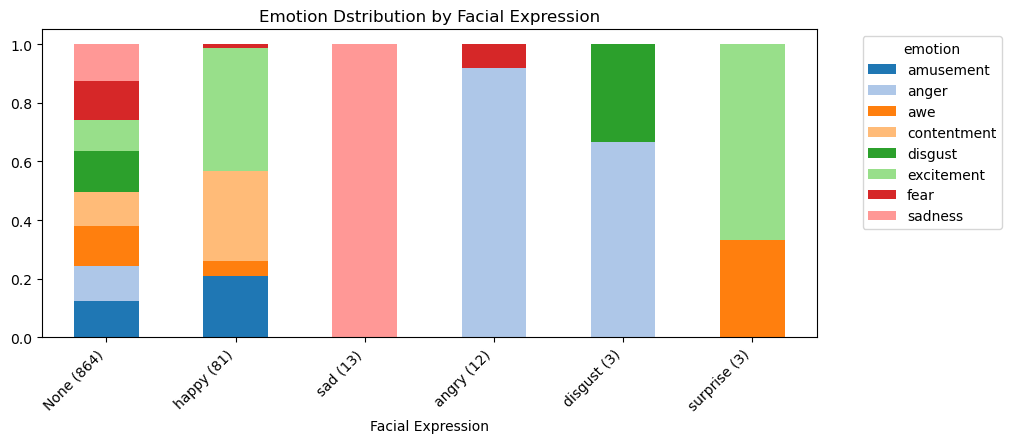

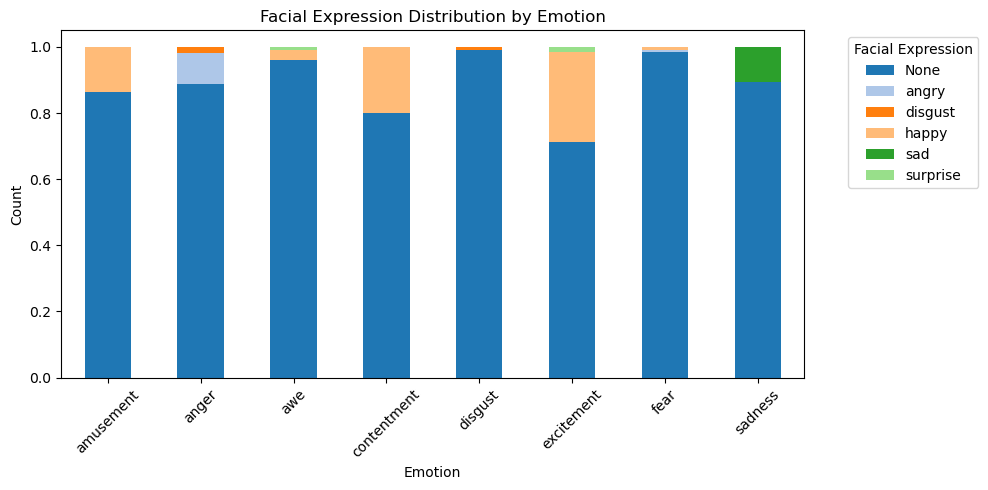

'\n--- Human Action DISTRIBUTION ---'

'Total unique categories: 41'

'Categories appearing >= 10 times: 2'

'Categories appearing >= 5 times: 8'

human_action
None                            862
laughing                         15
marching                          9
singing                           8
celebrating                       7
crying                            6
sticking tongue out               5
swinging on something             5
hugging                           4
motorcycling                      4
playing guitar                    4
stretching arm                    4
skiing                            3
surfing water                     3
playing bass guitar               3
carrying baby                     2
canoeing or kayaking              2
boxing                            2
crawling baby                     2
playing drums                     2
kicking soccer ball               2
reading book                      2
riding a bike                     2
riding or walking with horse      1
knitting                          1
dancing                           1
kitesurfing                       1
kissing        

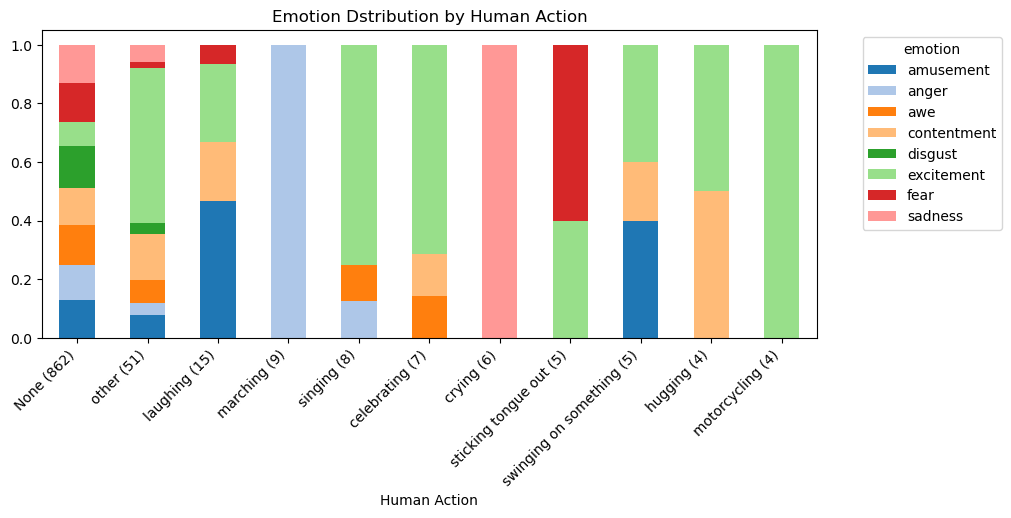

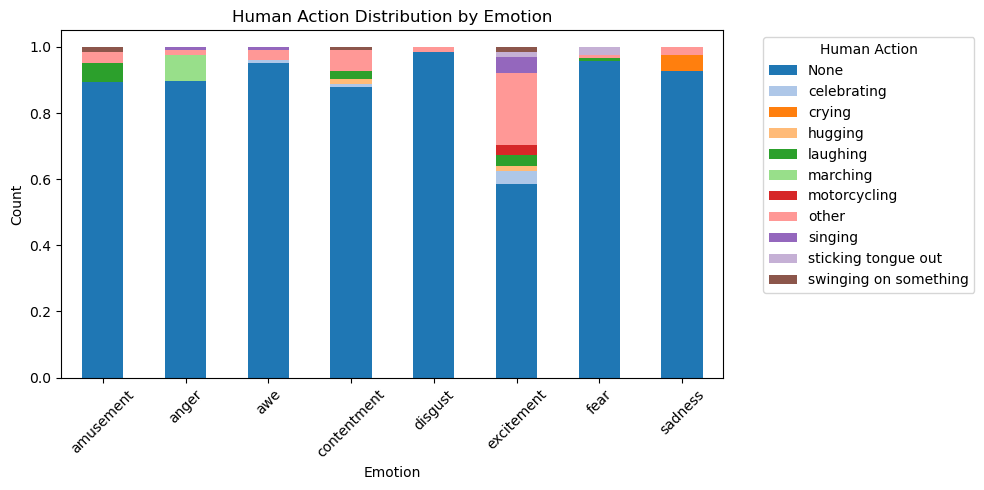

'\n--- Scene DISTRIBUTION ---'

'Total unique categories: 72'

'Categories appearing >= 10 times: 5'

'Categories appearing >= 5 times: 11'

scene
None              768
cemetery           24
amusement_park     15
sky                14
street             14
                 ... 
rope_bridge         1
corral              1
bedroom             1
harbor              1
discotheque         1
Name: count, Length: 72, dtype: int64

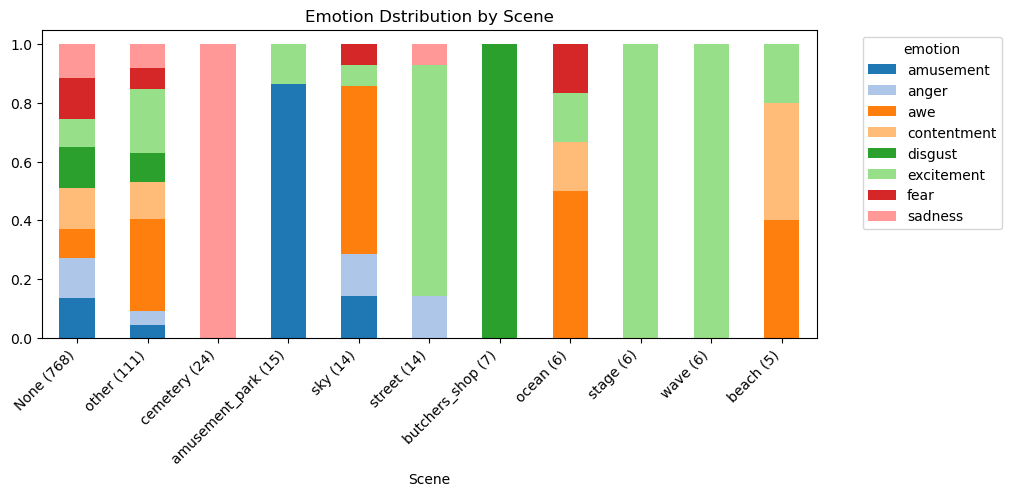

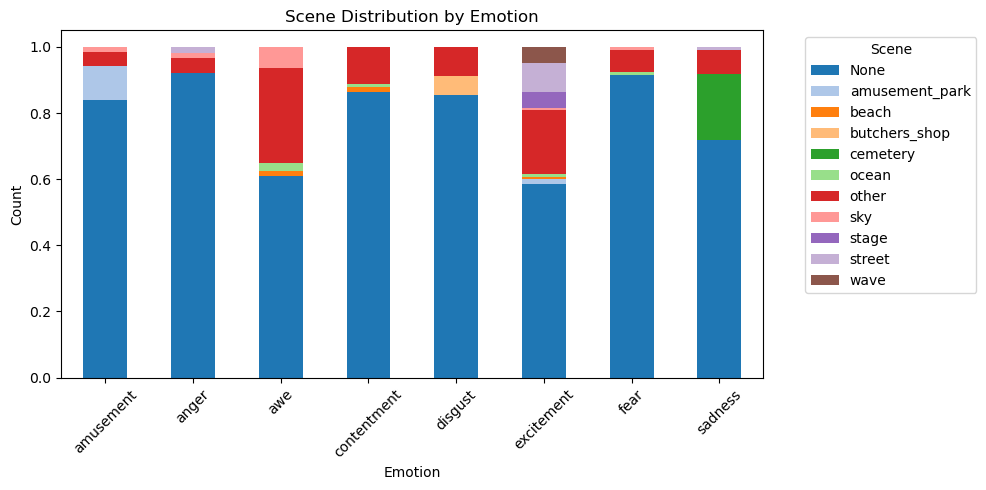

'\n--- Has Object DISTRIBUTION ---'

'Total unique categories: 2'

'Categories appearing >= 10 times: 2'

'Categories appearing >= 5 times: 2'

has_object
True     511
False    465
Name: count, dtype: int64

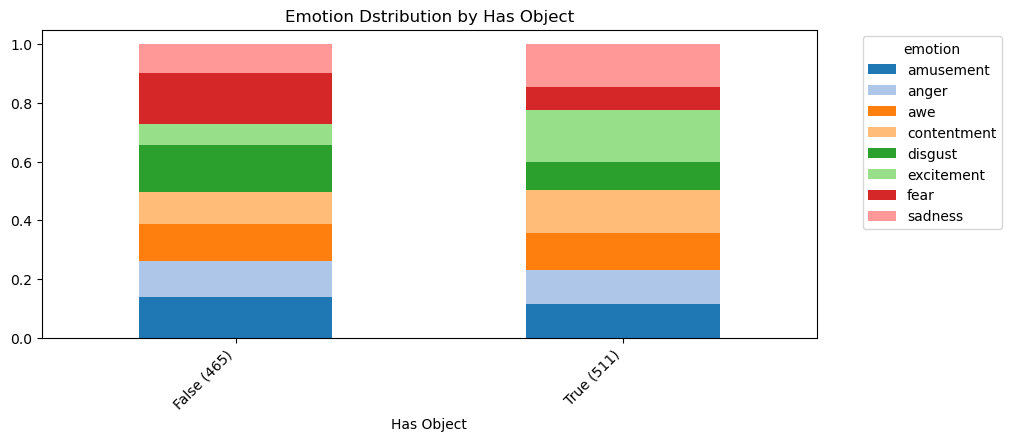

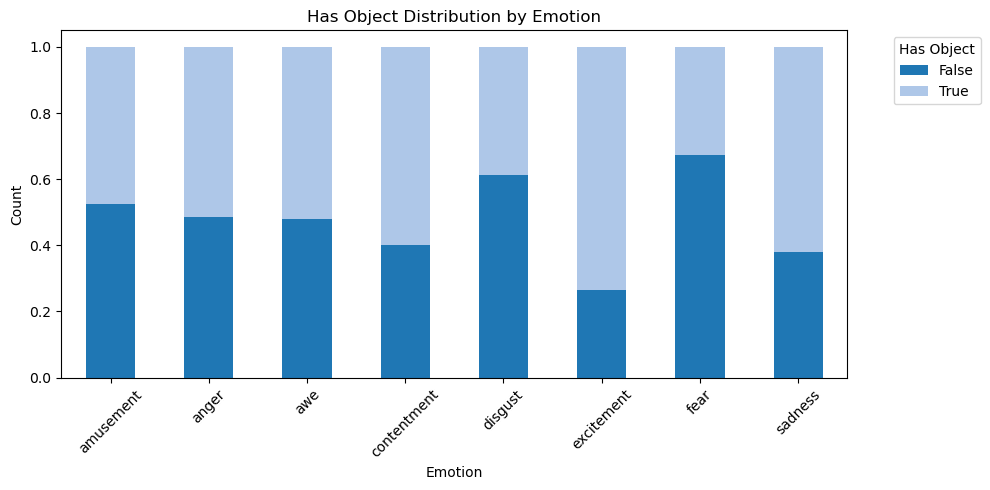

In [52]:


def categorical_eda(data, feature, top_k = 10):
    feature_title = feature.replace('_', ' ').title()
    counts = data[feature].value_counts(dropna=False)
    display(f"\n--- {feature_title} DISTRIBUTION ---")
    display(f"Total unique categories: {data[feature].nunique()}")
    display(f"Categories appearing >= 10 times: {(counts >= 10).sum()}")
    display(f"Categories appearing >= 5 times: {(counts >= 5).sum()}")
    display(counts)
    #display(df.groupby('emotion')[feature].value_counts())

    # If feature has many categories → limit to top-K

    #count occurrences (including NaNs)
    top_categories = counts.dropna().head(top_k).index

    copied_data = data.copy()
    copied_data[feature] = copied_data[feature].apply(lambda x: 'other' if x not in top_categories else x)
    adjusted_counts = copied_data[feature].value_counts(dropna=False)

    # plotting by feature
    by_feature = pd.crosstab(copied_data[feature], copied_data[LABEL_COLUMN], normalize='index')
    # If has_object is boolean, it will only have two categories: True/False (or 1/0)
    # So for boolean columns, skip sorting if only two categories:
    if copied_data[feature].dtype == 'bool':
        by_feature_sorted = by_feature
    else:
        sorted_categories = adjusted_counts.loc[by_feature.index].sort_values(ascending=False).index
        by_feature_sorted = by_feature.loc[sorted_categories]
    ax = by_feature_sorted.plot(kind='bar', stacked=True, figsize=(10, 4), color=cm.tab20.colors)
    tick_labels = [
        f"{cat} ({adjusted_counts[cat]})" if cat in adjusted_counts else f"{cat} (0)"
        for cat in by_feature_sorted.index
    ]
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    plt.title(f'Emotion Dstribution by {feature_title}')
    plt.xlabel(feature_title)
    plt.legend(
        title=LABEL_COLUMN,
        bbox_to_anchor=(1.05, 1)
    )
    plt.show()

    # plotting by emotion
    def plot_by_emotion(d):
        by_emotion = pd.crosstab(d[LABEL_COLUMN], d[feature], normalize='index')
        by_emotion.plot(kind='bar', stacked=True, figsize=(10, 5), color = cm.tab20.colors)
        plt.title(f"{feature_title} Distribution by Emotion")
        plt.xlabel("Emotion")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.legend(
            title=feature_title,
            bbox_to_anchor=(1.05, 1)
        )
        plt.tight_layout()
        plt.show()

    plot_by_emotion(copied_data)
        

# 4.2 Distribution of categorical
categorical_eda(df, 'facial_expression')
## takeaway - theres only 6 facial expressions available -> we can just use one hot encoding
categorical_eda(df, 'human_action')
## takeaway - there are 41 human actions, the vast majority of which only show up a couple of times -> encode any category that shows up less than 5 times as "other" OR just use a "has_human_action" column
categorical_eda(df, 'scene')
## takeaway - there are 71 scenes, some of which do have meaningful number of samples and impact on label -> encode any category that shows up less than X times as "other"
categorical_eda(df, 'has_object')
## takeaway - about 50/50 split and doesnt discriminate well between emotions -> look at actual objects

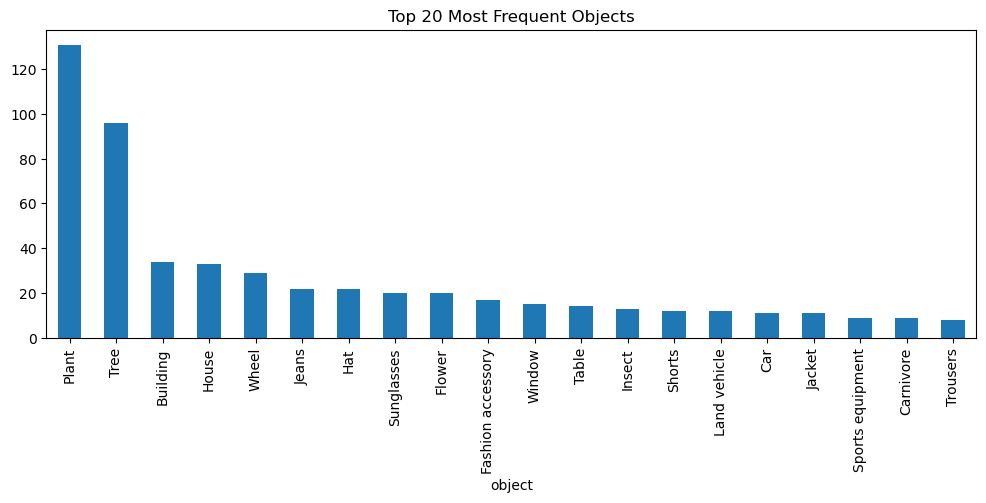

Total unique objects: 133
Objects appearing >= 10 times: 17
Objects appearing >= 5 times: 33


'\n--- Object DISTRIBUTION ---'

'Total unique categories: 133'

'Categories appearing >= 10 times: 17'

'Categories appearing >= 5 times: 33'

object
Plant        131
Tree          96
Building      34
House         33
Wheel         29
            ... 
Bust           1
Fireplace      1
Snack          1
Jaguar         1
Wine           1
Name: count, Length: 133, dtype: int64

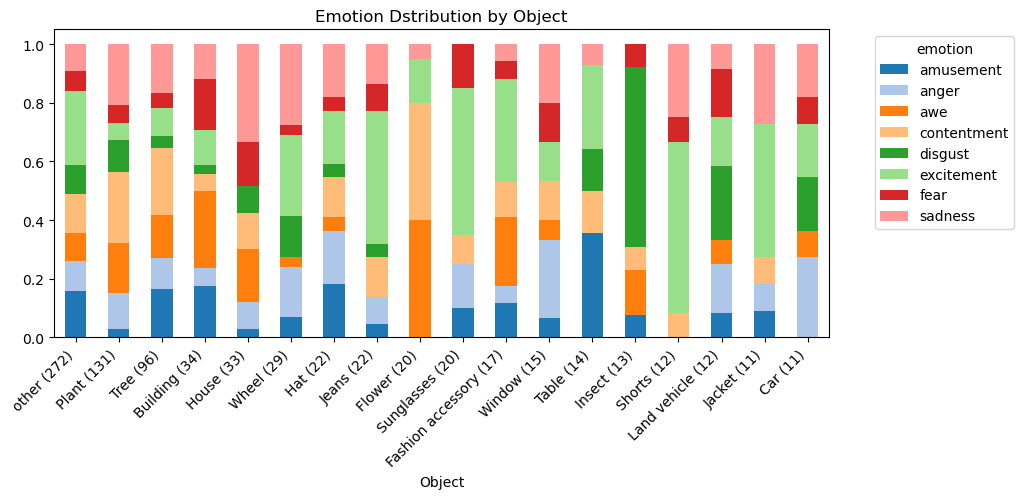

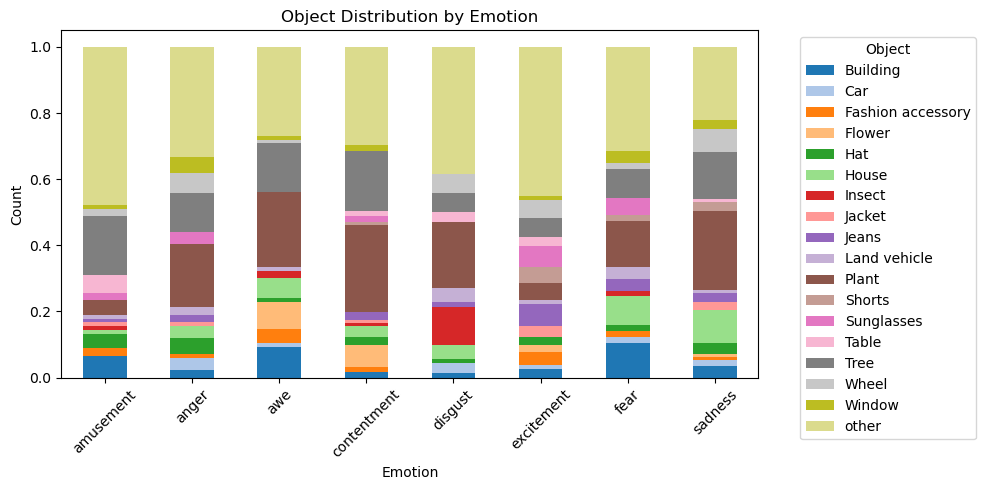

In [53]:
all_objects = df['object'].dropna().explode()

all_objects.value_counts().head(20).plot(kind='bar', figsize=(12, 4))
plt.title('Top 20 Most Frequent Objects')
plt.show()

print(f"Total unique objects: {all_objects.nunique()}")
print(f"Objects appearing >= 10 times: {(all_objects.value_counts() >= 10).sum()}")
print(f"Objects appearing >= 5 times: {(all_objects.value_counts() >= 5).sum()}")

object_emotion = (df[['emotion', 'object']]
    .explode('object')
    .dropna(subset=['object'])
    .reset_index(drop=True))

categorical_eda(object_emotion, 'object', top_k = 17)

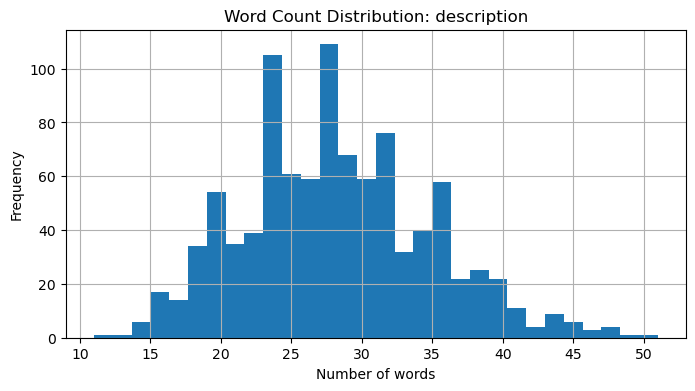

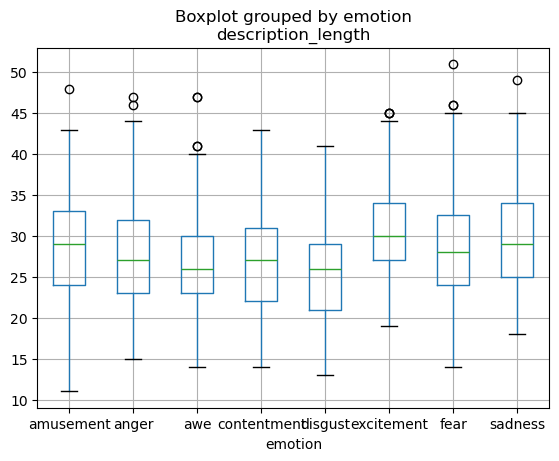

'description vocabulary size: 3076'

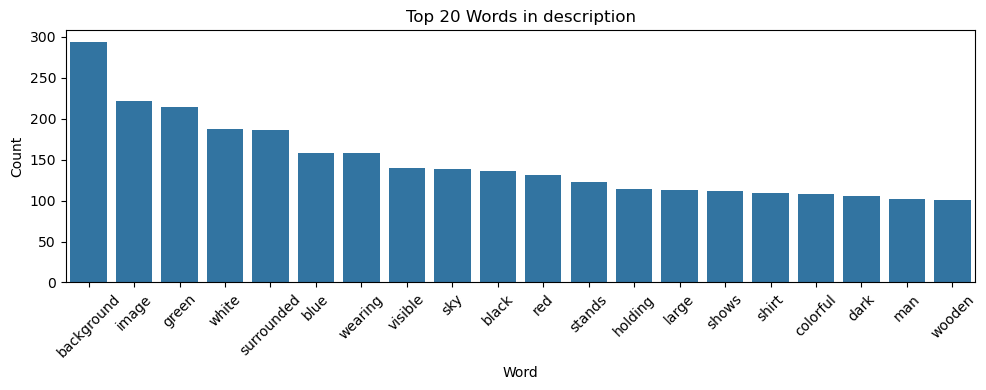

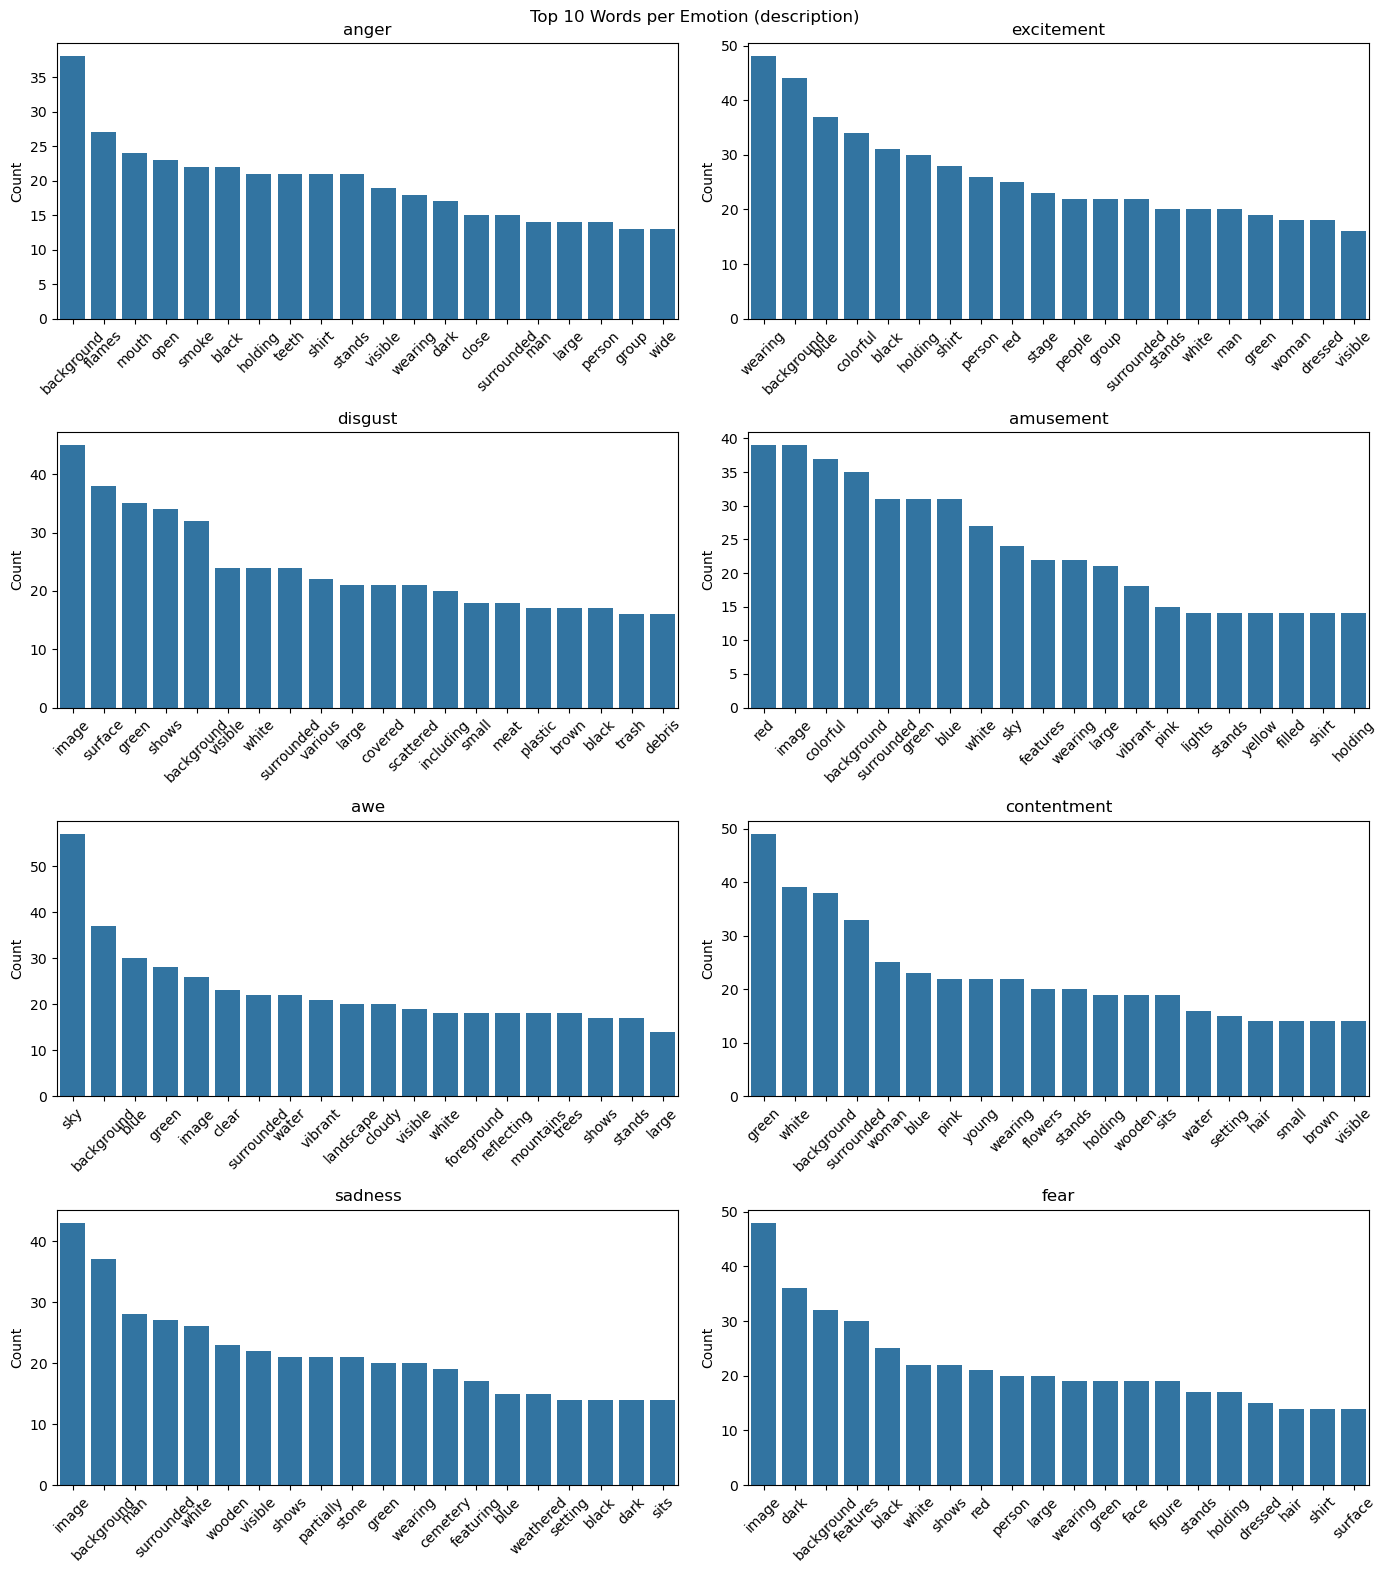

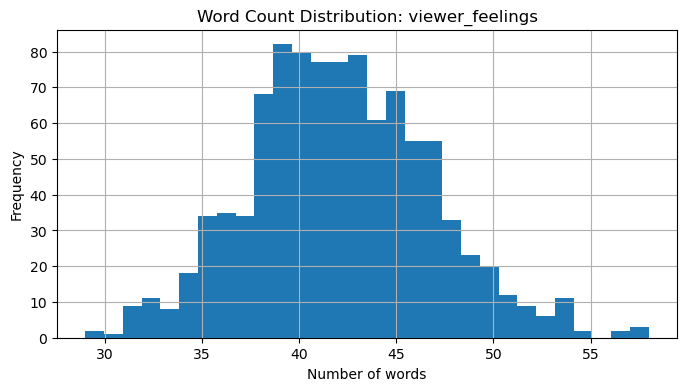

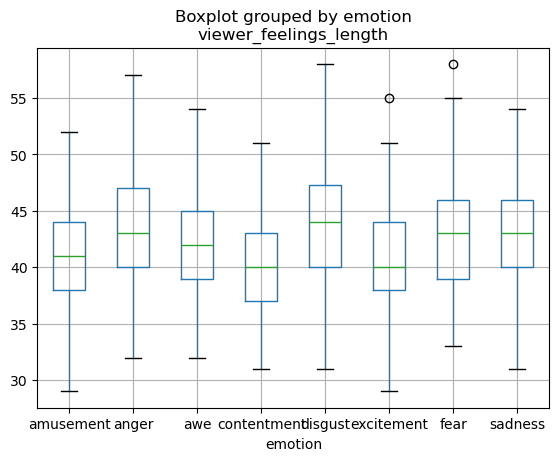

'viewer_feelings vocabulary size: 2659'

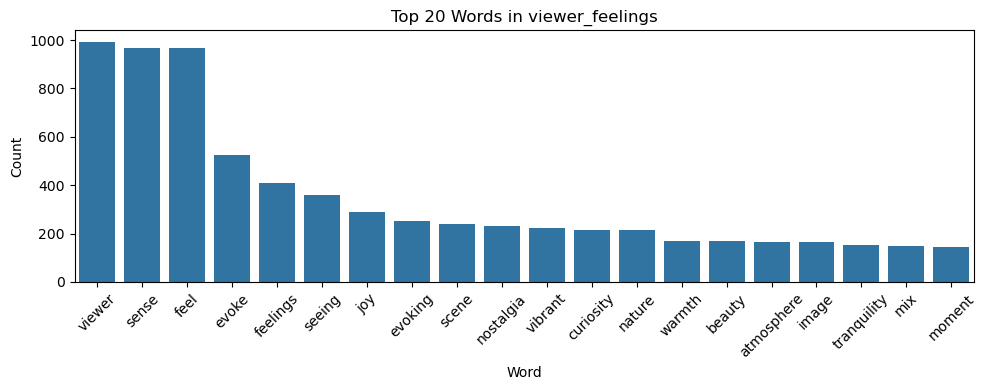

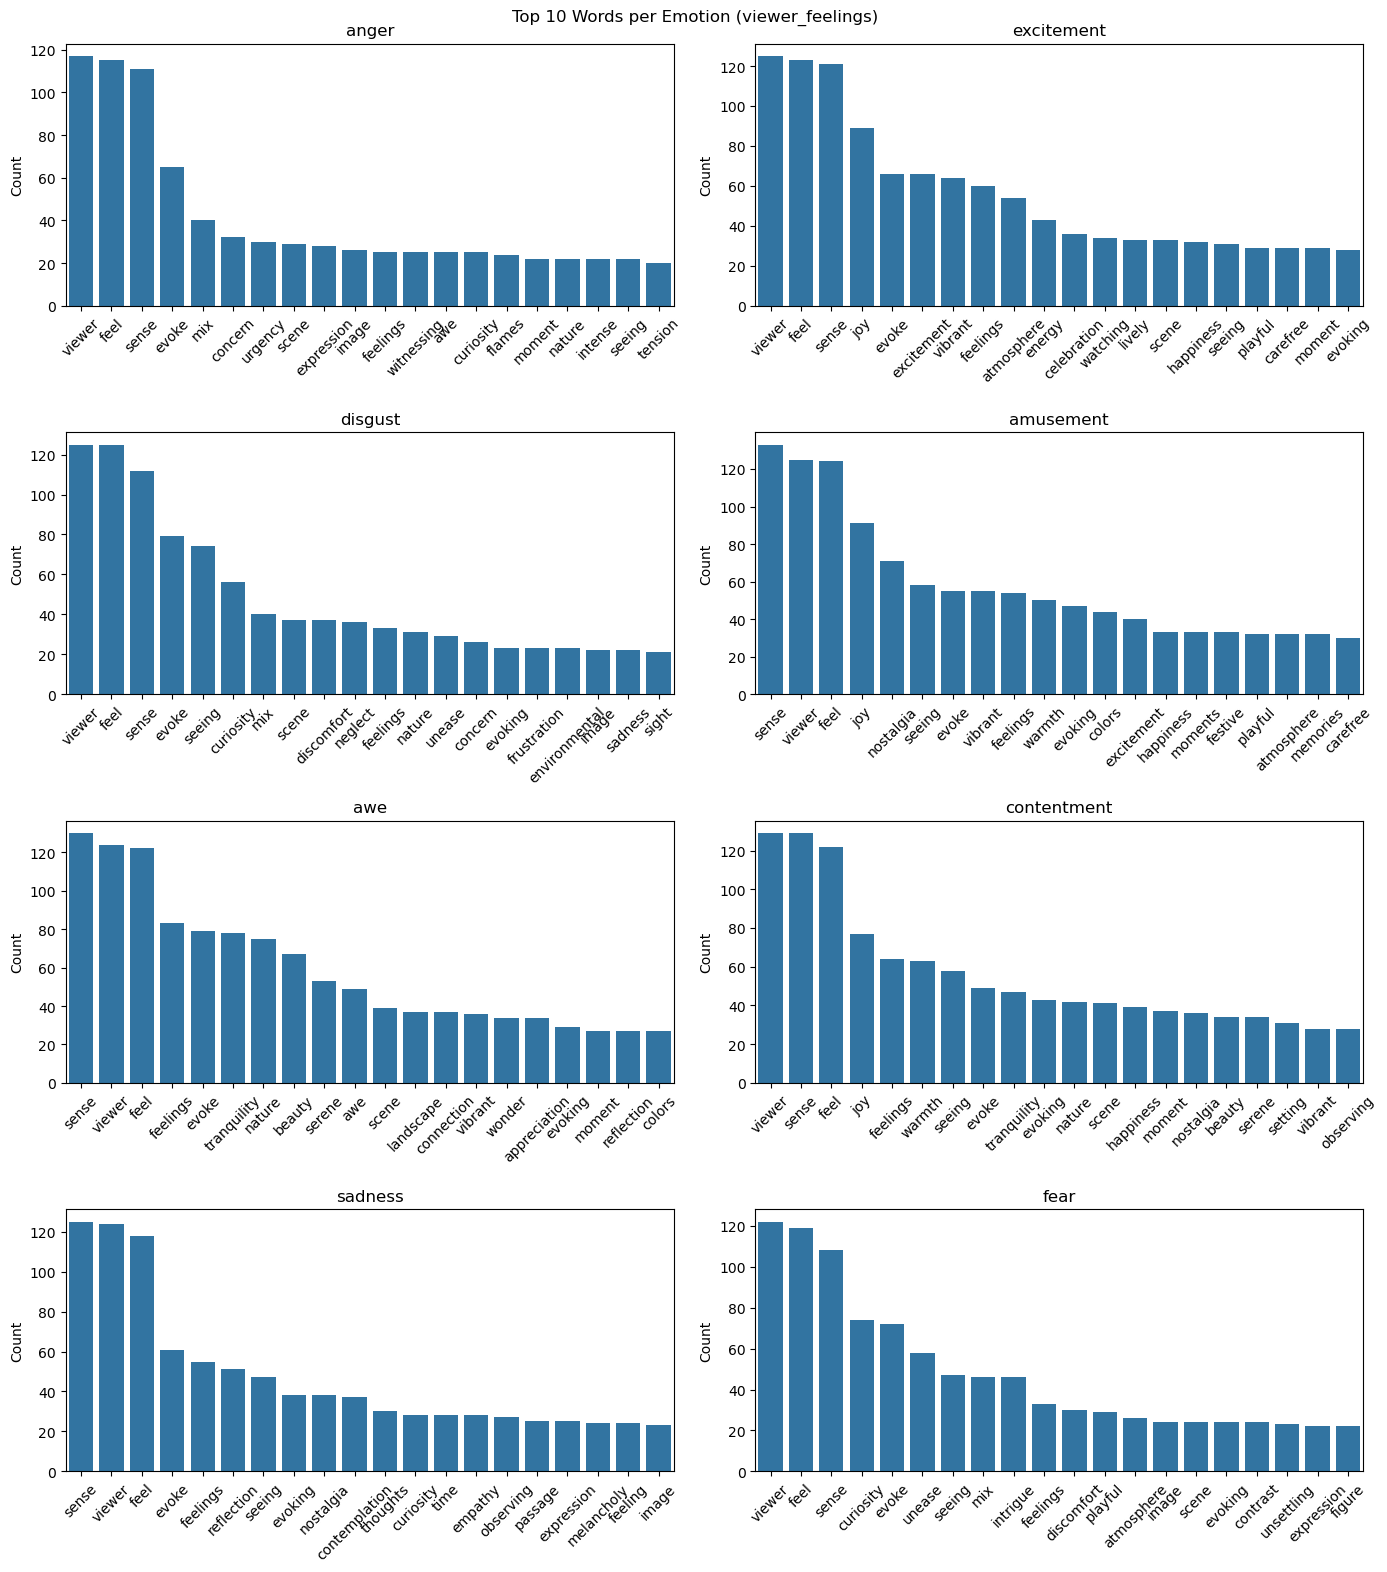

In [54]:
def text_eda(col):
    df[f'{col}_length'] = df[col].apply(lambda x: len(x.split()))

    #Plot histograms
    plt.figure(figsize=(8, 4))
    df[f'{col}_length'].hist(bins=30)
    plt.title(f"Word Count Distribution: {col}")
    plt.xlabel("Number of words")
    plt.ylabel("Frequency")
    plt.show()

    df.boxplot(column=f'{col}_length', by='emotion')
    plt.show()

    #Vocabulary size
    def get_vocab(text_series):
        words = []
        for text in text_series.dropna():
            text = text.lower()
            text = re.sub(r'[^a-z\s]', '', text)
            words.extend(text.split())
        return set(words)

    vocab = get_vocab(df[col])
    display(f"{col} vocabulary size: {len(vocab)}")

    #Most frequent words
    def get_top_words(text_series, top_k=20):
        vec = CountVectorizer(stop_words='english')
        counts = vec.fit_transform(text_series)
        word_counts = pd.Series(
            counts.sum(axis=0).A1,  # sum across all documents
            index=vec.get_feature_names_out()
        ).sort_values(ascending=False)
        return word_counts.sort_values(ascending=False).head(top_k)

    text = df[col]
    top_words = get_top_words(text)
    plt.figure(figsize=(10,4))
    sns.barplot(x=top_words.index, y=top_words.values)
    plt.title(f"Top 20 Words in {col}")
    plt.xlabel("Word")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(4, 2, figsize=(14, 16))
    for ax, emotion in zip(axes.flatten(), LABELS):
        emotion_top = get_top_words(df[df['emotion'] == emotion][col].dropna())
        sns.barplot(x=emotion_top.index, y=emotion_top.values, ax=ax)
        ax.set_title(f'{emotion}')
        ax.set_xlabel('')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'Top 10 Words per Emotion ({col})')
    plt.tight_layout()
    plt.show()

for col in TEXT_COLUMNS:
    text_eda(col)

In [55]:
def display_pca_by_emotion(n_components, x, y, title):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(x)

    #Plot and color by emotion
    plt.figure(figsize=(8, 6))

    for emotion in y.unique():
        idx = y == emotion
        plt.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=emotion,
            alpha=0.6
        )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

    display("Explained variance ratio:", pca.explained_variance_ratio_)
    display("Total explained variance:", pca.explained_variance_ratio_.sum())

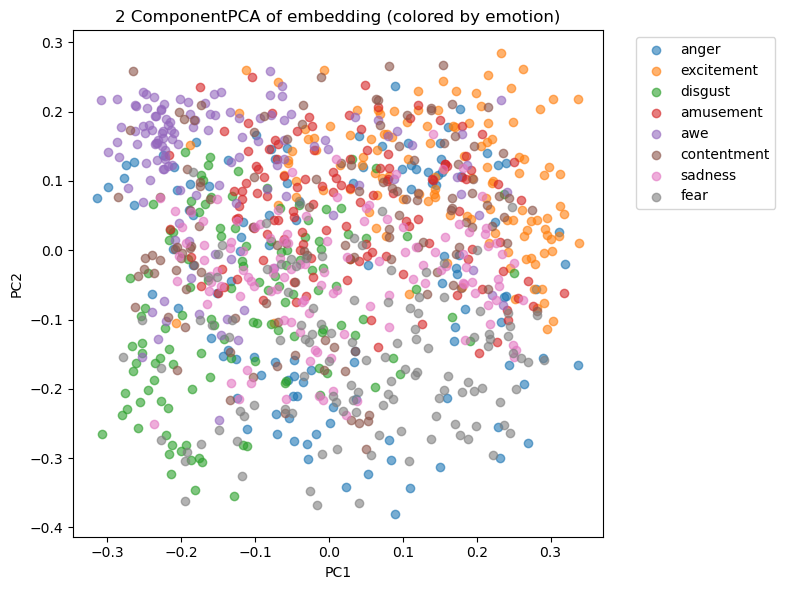

'Explained variance ratio:'

array([0.05484949, 0.04256617])

'Total explained variance:'

np.float64(0.09741565289181323)

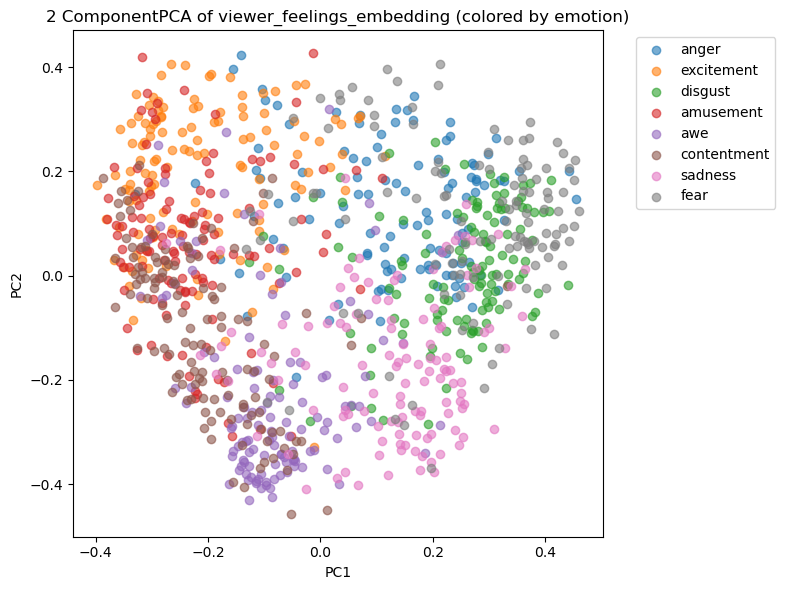

'Explained variance ratio:'

array([0.1072946 , 0.08154834])

'Total explained variance:'

np.float64(0.18884293810769837)

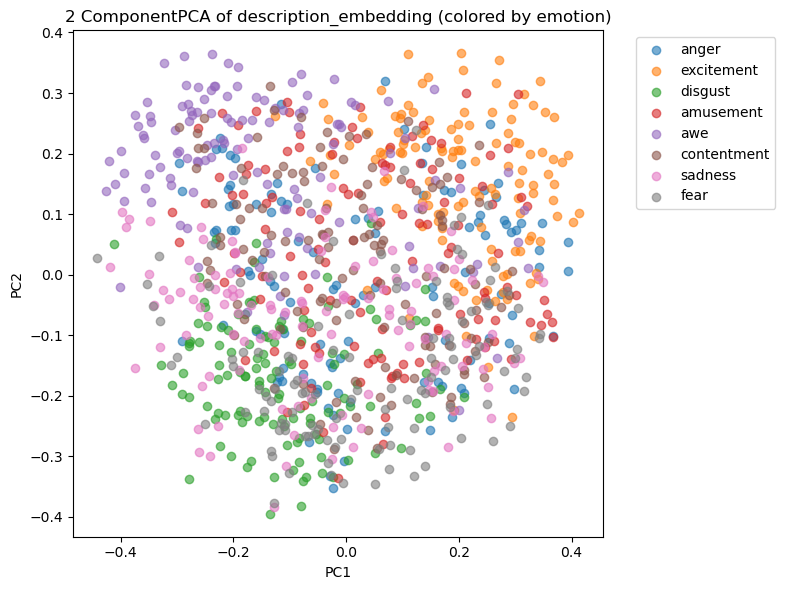

'Explained variance ratio:'

array([0.04949997, 0.04021613])

'Total explained variance:'

np.float64(0.08971610060322374)

In [56]:
# Embedding - run PCA
for col in EMBEDDING_COLUMNS:
    X_PCA = np.vstack(df[col].values)
    display_pca_by_emotion(2, X_PCA, df[LABEL_COLUMN], f'2 ComponentPCA of {col} (colored by emotion)')
    

In [57]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('emotion', axis=1), df['emotion'], random_state=0, test_size=0.2
)

'TFIDF ANALYSIS FOR VIEWER FEELINGS'

'TF–IDF shape: (780, 200)'

'Vocabulary size: 200'

'Top words for emotion: anger'

array(['tension', 'image', 'awe', 'intense', 'expression', 'flames',
       'witnessing', 'concern', 'mix', 'urgency'], dtype=object)

...

array(['evoking', 'serene', 'scene', 'nature', 'seeing', 'tranquility',
       'happiness', 'feelings', 'joy', 'warmth'], dtype=object)

'Top words for emotion: sadness'

array(['empathy', 'seeing', 'feelings', 'nostalgia', 'melancholy',
       'passage', 'thoughts', 'time', 'contemplation', 'reflection'],
      dtype=object)

'Top words for emotion: fear'

array(['amusement', 'figure', 'discomfort', 'playful', 'seeing', 'eerie',
       'mix', 'intrigue', 'unease', 'curiosity'], dtype=object)

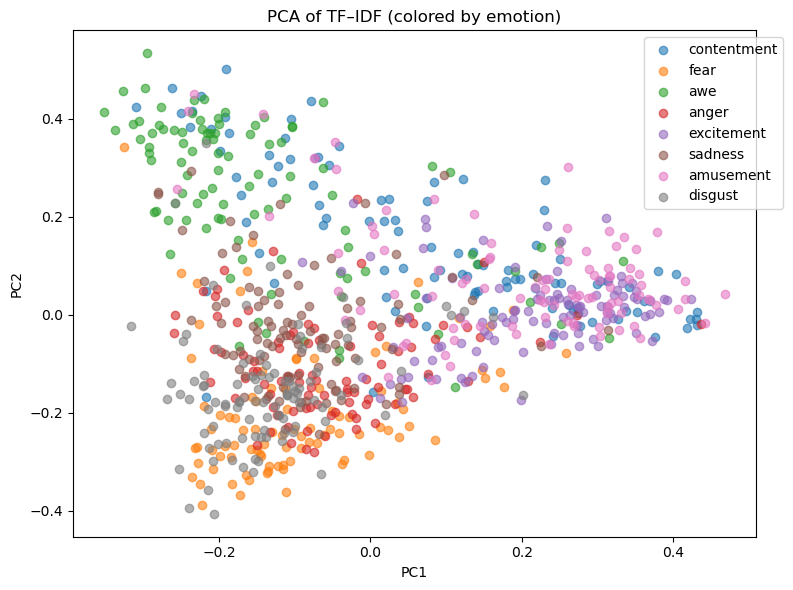

'Explained variance ratio:'

array([0.04023772, 0.03778988])

'Total explained variance:'

np.float64(0.07802759634792103)

'TFIDF ANALYSIS FOR DESCRIPTION'

...

array(['blue', 'background', 'young', 'wearing', 'woman', 'pink',
       'flowers', 'surrounded', 'white', 'green'], dtype=object)

'Top words for emotion: sadness'

array(['shows', 'wooden', 'weathered', 'stone', 'white', 'partially',
       'man', 'background', 'cemetery', 'image'], dtype=object)

'Top words for emotion: fear'

array(['shows', 'surface', 'background', 'figure', 'black', 'face',
       'large', 'dark', 'features', 'image'], dtype=object)

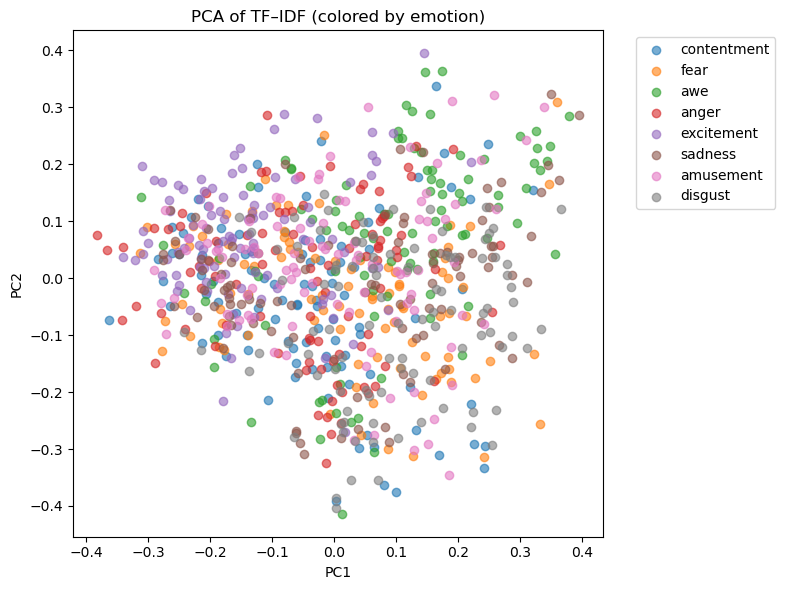

'Explained variance ratio:'

array([0.0288811 , 0.02159853])

'Total explained variance:'

np.float64(0.0504796241457032)

'Description vocab size:'

...

31

'Overlap ratio (desc):'

0.155

'Overlap ratio (feelings):'

0.155

In [58]:
def analyze_tfidf(vectorizer, x, y):
    display(f"TF–IDF shape: {x.shape}")

    #sanity-check - Vocabulary size
    display(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

    #Top TF–IDF words per emotion
    feature_names = np.array(vectorizer.get_feature_names_out())

    for emotion in LABELS:
        idx = (y == emotion).values
        mean_tfidf = x[idx].mean(axis=0)
        top_indices = np.argsort(mean_tfidf.A1)[-10:]

        display(f"Top words for emotion: {emotion}")
        display(feature_names[top_indices])

    # PCA
    X_tfidf_dense = x.toarray()
    display_pca_by_emotion(2, X_tfidf_dense, y, "PCA of TF–IDF (colored by emotion)")

# TF–IDF vectorizer
vectorizer_params = {
    "sublinear_tf": True,
    "max_df": 0.5,
    "min_df": 3,
    "stop_words": "english",
    "max_features": 200,
    "analyzer": "word"
}

# TF-IDF on Viewer Feelings
display("TFIDF ANALYSIS FOR VIEWER FEELINGS")

feelings_vectorizer = TfidfVectorizer(**vectorizer_params)
train_feelings_tfidf = feelings_vectorizer.fit_transform(X_train['viewer_feelings'])
analyze_tfidf(feelings_vectorizer, train_feelings_tfidf, y_train)


# TF–IDF on descriptions    
display("TFIDF ANALYSIS FOR DESCRIPTION")

description_vectorizer = TfidfVectorizer(**vectorizer_params)
train_description_tfidf = description_vectorizer.fit_transform(X_train['description'])
analyze_tfidf(description_vectorizer, train_description_tfidf, y_train)

#Vocabulary overlap
desc_vocab = set(description_vectorizer.vocabulary_.keys())
feel_vocab = set(feelings_vectorizer.vocabulary_.keys())

overlap = desc_vocab.intersection(feel_vocab)

display("Description vocab size:", len(desc_vocab))
display("Viewer feelings vocab size:", len(feel_vocab))
display("Shared vocabulary size:", len(overlap))
display("Overlap ratio (desc):", len(overlap) / len(desc_vocab))
display("Overlap ratio (feelings):", len(overlap) / len(feel_vocab))

In [59]:
# For columns with many categories, replace any category that shows up less than 5 times with "other"
human_action_counts = X_train['human_action'].value_counts()
prevalent_human_actions = set(human_action_counts[human_action_counts >= 5].index)
scene_counts = X_train['scene'].value_counts()
prevalent_scenes = set(scene_counts[scene_counts >= 5].index)

def replace_with_other(data): 
    data['human_action'] = data['human_action'].apply(lambda x: 'other' if x not in prevalent_human_actions else x)
    data['scene'] = data['scene'].apply(lambda x: 'other' if x not in prevalent_scenes else x)

# One-hot encoding for categorical variables
def get_metadata_features(train, test): 
    replace_with_other(train)
    replace_with_other(test)
    train_categorical = pd.get_dummies(train[CATEGORICAL_METADATA].fillna('missing'))
    test_categorical  = pd.get_dummies(test[CATEGORICAL_METADATA].fillna('missing'))
    test_categorical  = test_categorical.reindex(columns=train_categorical.columns, fill_value=False)
 
    train_metadata = sparse.hstack([train[NUMERIC_METADATA], sparse.csr_matrix(train_categorical.values)])
    test_metadata  = sparse.hstack([test[NUMERIC_METADATA],  sparse.csr_matrix(test_categorical.values)])


    metadata_feature_names = NUMERIC_METADATA + train_categorical.columns.tolist()
 
    return train_metadata, test_metadata, metadata_feature_names


train_metadata, test_metadata, metadata_feature_names = get_metadata_features(X_train, X_test)

def select_k_best(train, test, y, vectorizer, k):
    selector = SelectKBest(chi2, k=k)  # keep top k TF-IDF features
    selector.fit(train, y)  # fit on train only

    X_train_text = selector.transform(train)
    X_test_text  = selector.transform(test)
    all_feature_names = vectorizer.get_feature_names_out()
    selected_feature_names = all_feature_names[selector.get_support()]
    
    return X_train_text, X_test_text, selected_feature_names

test_description_tfidf = description_vectorizer.transform(X_test['description'])
test_feelings_tfidf = feelings_vectorizer.transform(X_test['viewer_feelings'])

k_best_train_feelings_tfidf, k_best_test_feelings_tfidf, k_best_feelings_feature_names = select_k_best(train_feelings_tfidf, test_feelings_tfidf, y_train, feelings_vectorizer, 60)
k_best_train_description_tfidf, k_best_test_description_tfidf, k_best_description_feature_names = select_k_best(train_description_tfidf, test_description_tfidf, y_train, description_vectorizer, 60)

X_train_sparse = sparse.hstack([train_metadata, k_best_train_feelings_tfidf, k_best_train_description_tfidf])
X_test_sparse = sparse.hstack([test_metadata, k_best_test_feelings_tfidf, k_best_test_description_tfidf])

# Create feature_names for all columns in X
viewer_feelings_feature_names = ['viewer_feelings_tfidf_' + str(word) for word in k_best_feelings_feature_names]
description_feature_names = ['description_tfidf_' + str(word) for word in k_best_description_feature_names]
feature_names = metadata_feature_names + viewer_feelings_feature_names + description_feature_names

print(f'Number of features in feature_names: {len(feature_names)}')

Number of features in feature_names: 149


In [60]:
param_grids = [
    {
        'estimator': RandomForestClassifier(random_state=42),
        'param_grid': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
        }
    },
    {
        'estimator': GradientBoostingClassifier(random_state=42),
        'param_grid': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
        }
    },
    {
        'estimator': RidgeClassifier(),
        'param_grid': {
            'alpha': [0.1, 1.0, 10.0],
        }
    },
    {      
        'estimator': LogisticRegression(max_iter=1000),
        'param_grid': {
        'C': [0.1, 1.0, 10.0],
        }
    },
    {
        'estimator': KNeighborsClassifier(),
        'param_grid': {
            'n_neighbors': [3, 5, 10],
        }
    }
]


best_score = 0
best_estimator = None
best_clf = None
best_params = None

for param_grid in param_grids:
    clf_name = param_grid['estimator'].__class__.__name__
    print(f"Searching {clf_name}...")
    
    grid = GridSearchCV(
        param_grid['estimator'], 
        param_grid['param_grid'], 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1  # use all cores
    )
    grid.fit(X_train_sparse, y_train)
    
    print(f"  Best CV accuracy: {grid.best_score_*100:.2f}%")
    print(f"  Best params: {grid.best_params_}")
    
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_estimator = grid.best_estimator_
        best_params = grid.best_params_
        best_clf = best_estimator    

Searching RandomForestClassifier...
  Best CV accuracy: 65.51%
  Best params: {'max_depth': 20, 'n_estimators': 200}
Searching GradientBoostingClassifier...
  Best CV accuracy: 63.59%
  Best params: {'learning_rate': 0.05, 'n_estimators': 100}
Searching RidgeClassifier...
  Best CV accuracy: 68.85%
  Best params: {'alpha': 1.0}
Searching LogisticRegression...
  Best CV accuracy: 67.44%
  Best params: {'C': 1.0}
Searching KNeighborsClassifier...
  Best CV accuracy: 53.08%
  Best params: {'n_neighbors': 5}


In [61]:
# Final evaluation on held-out test set
print(f"\nBest overall model: {best_clf.__class__.__name__}")
print(f"Best CV accuracy: {best_score*100:.2f}%")
best_y_pred = best_estimator.predict(X_test_sparse)
best_accuracy = accuracy_score(y_test, best_y_pred)
print(f"Test accuracy: {best_accuracy*100:.2f}%")


Best overall model: RidgeClassifier
Best CV accuracy: 68.85%
Test accuracy: 73.98%


              precision    recall  f1-score   support

   amusement       0.77      0.63      0.69        27
       anger       0.86      0.82      0.84        22
         awe       0.74      0.71      0.72        24
 contentment       0.58      0.76      0.66        25
     disgust       0.86      0.69      0.77        26
  excitement       0.71      0.87      0.78        23
        fear       0.76      0.70      0.73        27
     sadness       0.74      0.77      0.76        22

    accuracy                           0.74       196
   macro avg       0.75      0.74      0.74       196
weighted avg       0.75      0.74      0.74       196


Top Features:
viewer_feelings_tfidf_joy: 4.8185
description_tfidf_teeth: 3.8490
viewer_feelings_tfidf_awe: 3.7734
viewer_feelings_tfidf_festive: 3.3769
viewer_feelings_tfidf_tranquility: 3.2773
description_tfidf_meat: 3.2506
description_tfidf_parade: 3.2186
viewer_feelings_tfidf_eerie: 3.0528
description_tfidf_flowers: 2.9767
description_tfidf_fl

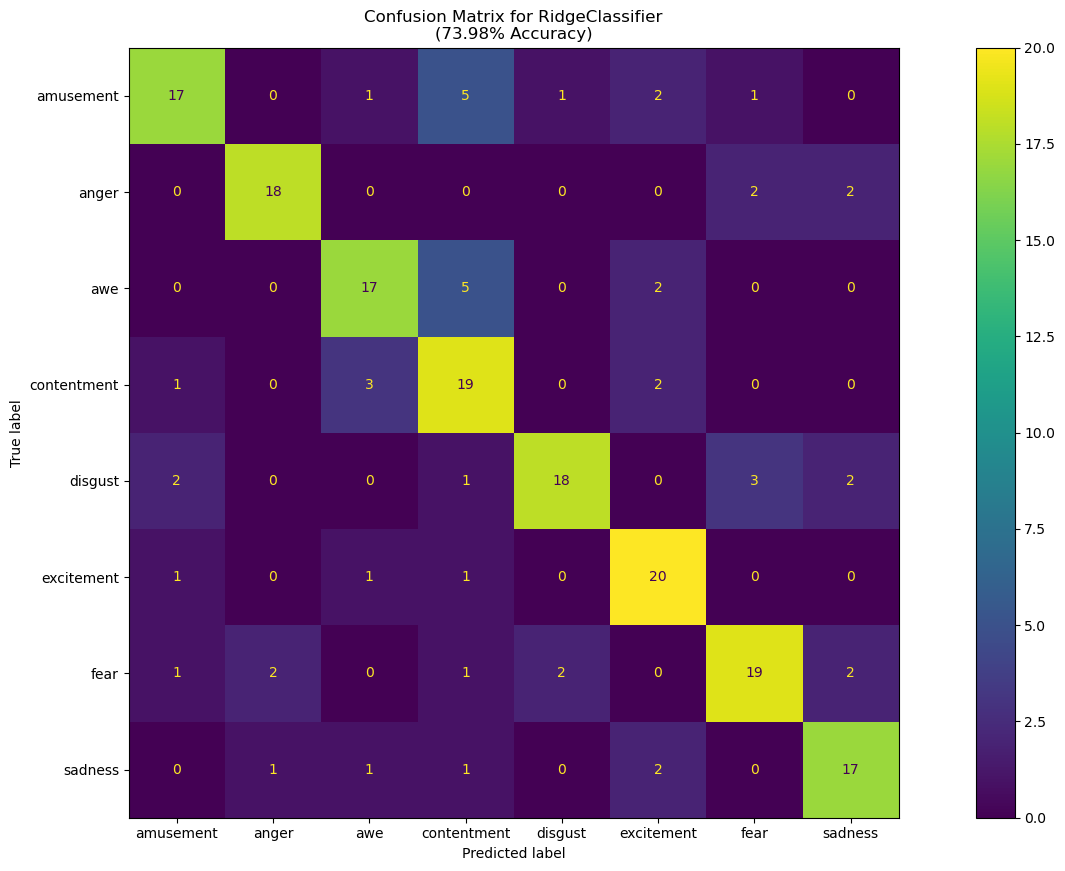

In [62]:
print(classification_report(y_test, best_y_pred))
fig, ax = plt.subplots(figsize=(20, 10))
ConfusionMatrixDisplay.from_predictions(y_test, best_y_pred, ax=ax)
_ = ax.set_title(
    f"Confusion Matrix for {best_clf.__class__.__name__}\n({best_accuracy * 100:.2f}% Accuracy)"
)

importances = best_clf.feature_importances_ if hasattr(best_clf, "feature_importances_") else np.sum(np.abs(best_clf.coef_), axis=0)
indices = np.argsort(importances)[::-1][:10]
print("\nTop Features:")
for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

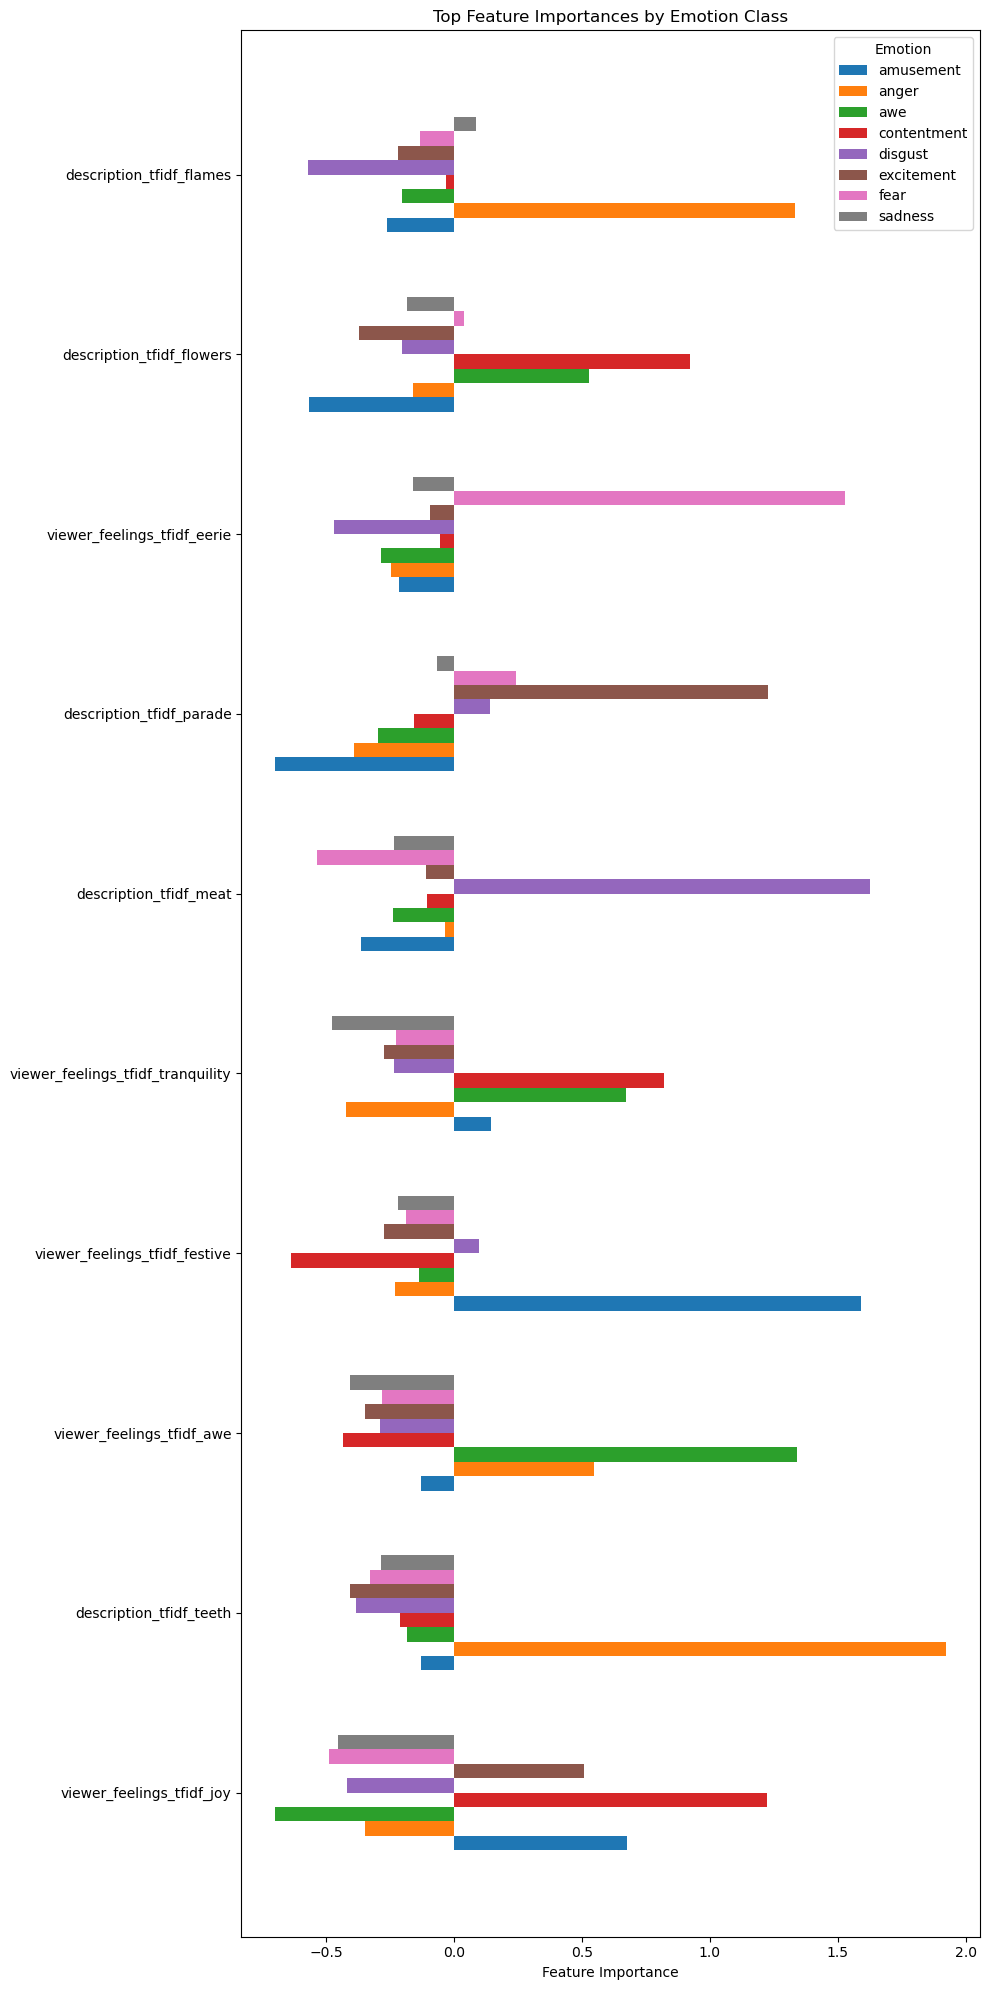

In [63]:
# Get feature importances or coefficients for each emotion class
if hasattr(best_clf, "feature_importances_"):
    # Tree models like RandomForest, GradientBoosting
    feature_importances = best_clf.feature_importances_.reshape(1, -1)
    emotion_labels = [best_clf.classes_[0] if hasattr(best_clf, "classes_") else "emotion"]
elif hasattr(best_clf, "coef_"):
    # Linear models: shape (n_classes, n_features)
    feature_importances = best_clf.coef_
    emotion_labels = best_clf.classes_
else:
    raise ValueError("The best model does not provide feature importances or coefficients.")

# If multiclass: feature_importances is (n_classes, n_features)
fig, ax = plt.subplots(figsize=(10, 20))  # Tall vertical plot
bar_width = 0.08
n_features = feature_importances.shape[1]
n_classes = feature_importances.shape[0]

# Get top N features overall for visualization
topn = 10
mean_importances = np.mean(np.abs(feature_importances), axis=0)
top_feature_indices = np.argsort(mean_importances)[::-1][:topn]
top_feature_names = [feature_names[i] for i in top_feature_indices]

y = np.arange(topn)
for i, emotion in enumerate(emotion_labels):
    importances = feature_importances[i, top_feature_indices]
    ax.barh(y + i*bar_width, importances, height=bar_width, label=str(emotion))

ax.set_yticks(y + (n_classes-1)*bar_width/2)
ax.set_yticklabels(top_feature_names)
ax.set_xlabel("Feature Importance")
ax.set_title("Top Feature Importances by Emotion Class")
ax.legend(title="Emotion")
plt.tight_layout()
plt.show()

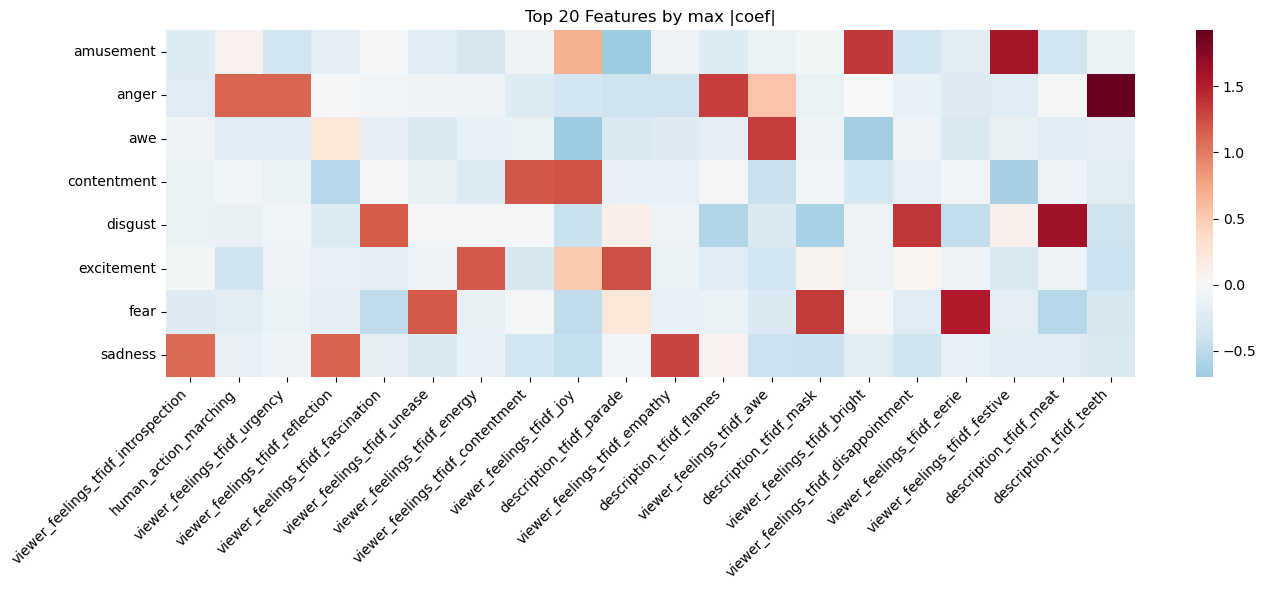

In [64]:
def plot_top_features_heatmap(model, n_top=20):
    coefs = model.coef_   

    # Pick top n_top features by max absolute coefficient across any class
    max_abs = np.abs(coefs).max(axis=0)
    top_idx = np.argsort(max_abs)[-n_top:]

    top_coefs = coefs[:, top_idx]
    top_names = [feature_names[j].split('__')[-1] for j in top_idx]

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        top_coefs,
        xticklabels=top_names,
        yticklabels=model.classes_,
        cmap='RdBu_r',    # red = positive, blue = negative
        center=0,
        #cmap='RdYlGn',    # red = negative, green = positive
        ax=ax
    )
    
    ax.set_title('Top 20 Features by max |coef|')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('task1_heatmap.png', dpi=150)
    plt.show()

plot_top_features_heatmap(best_clf)

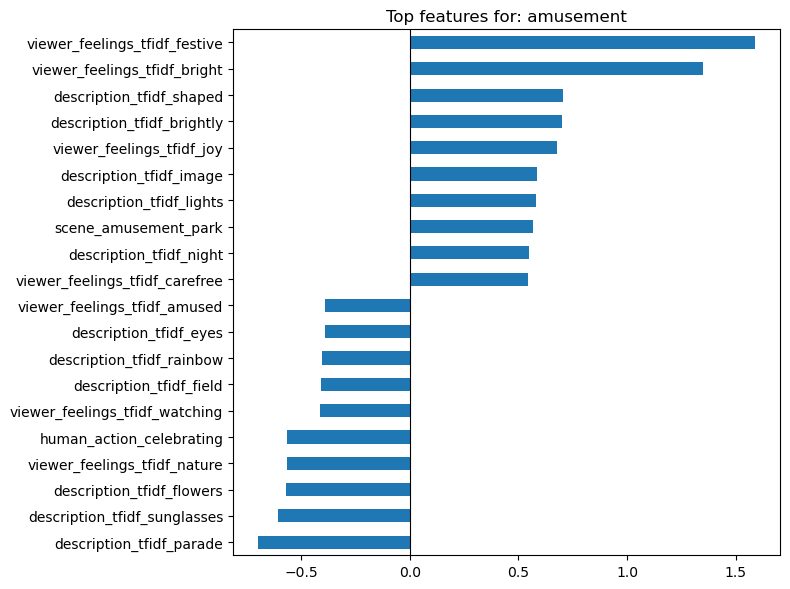

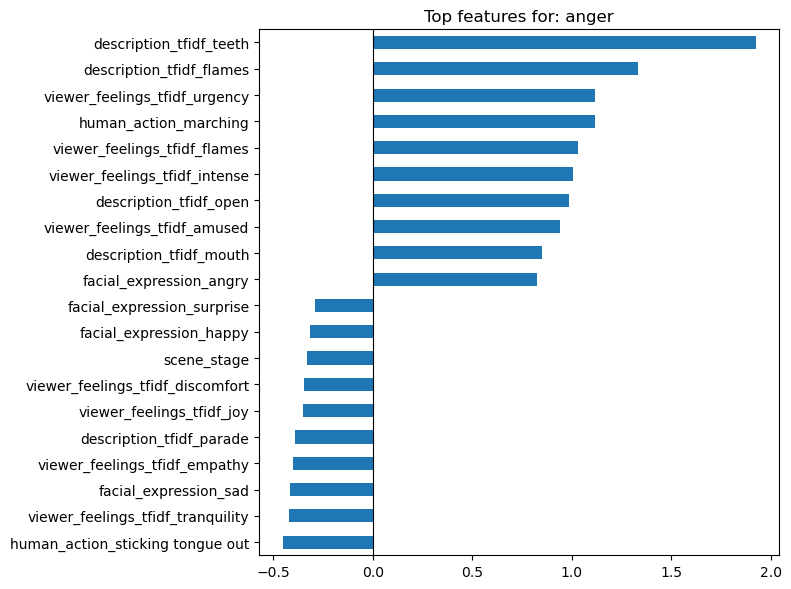

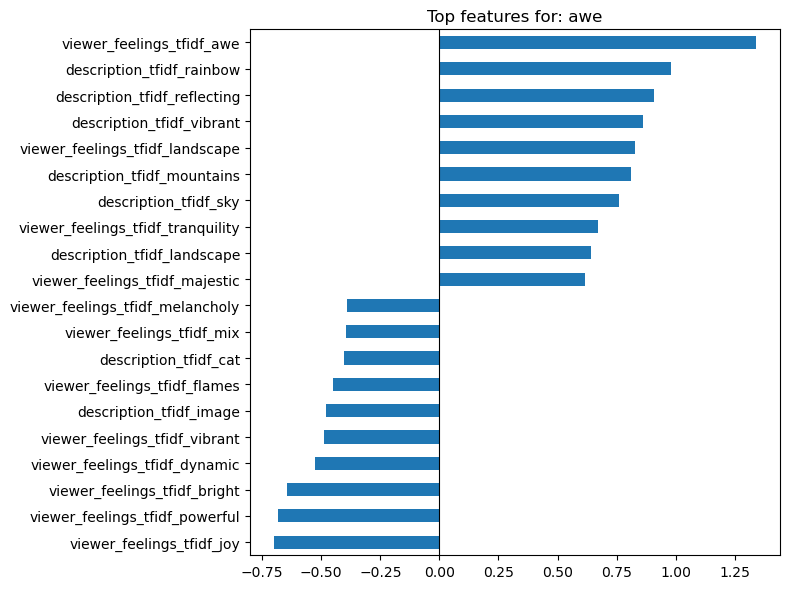

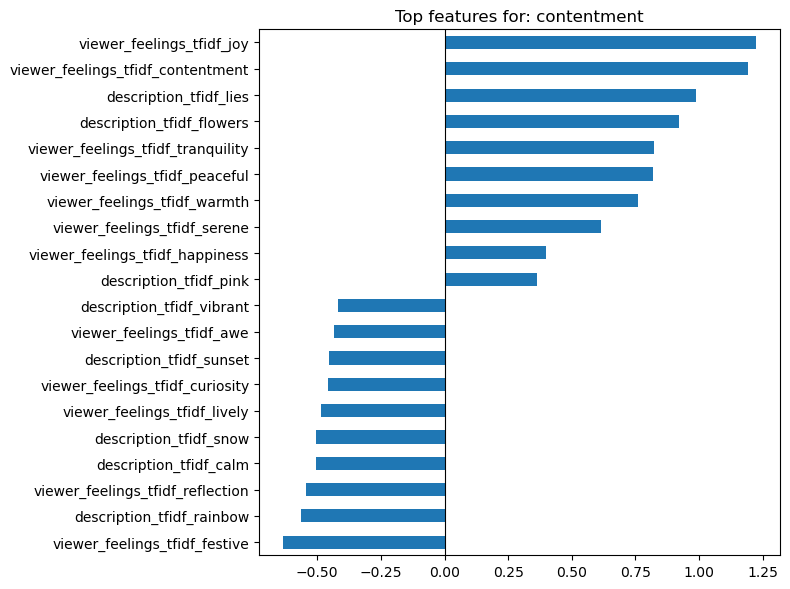

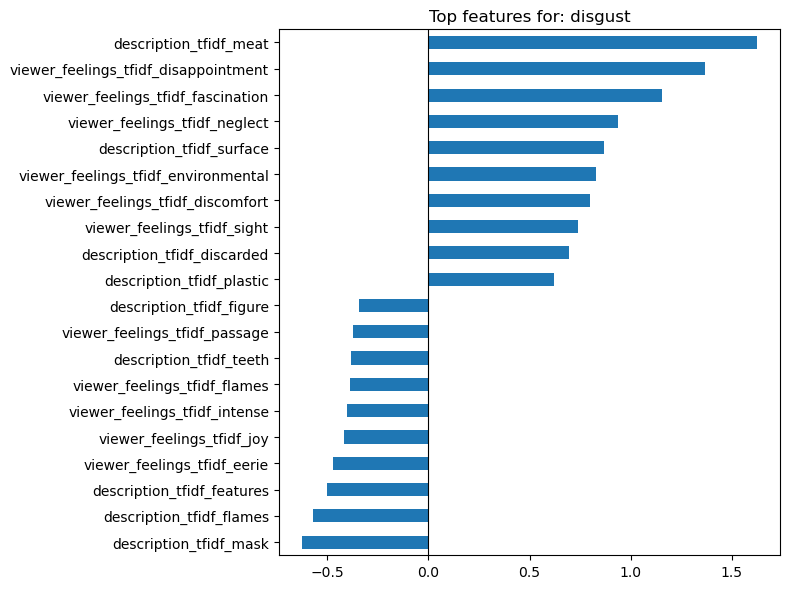

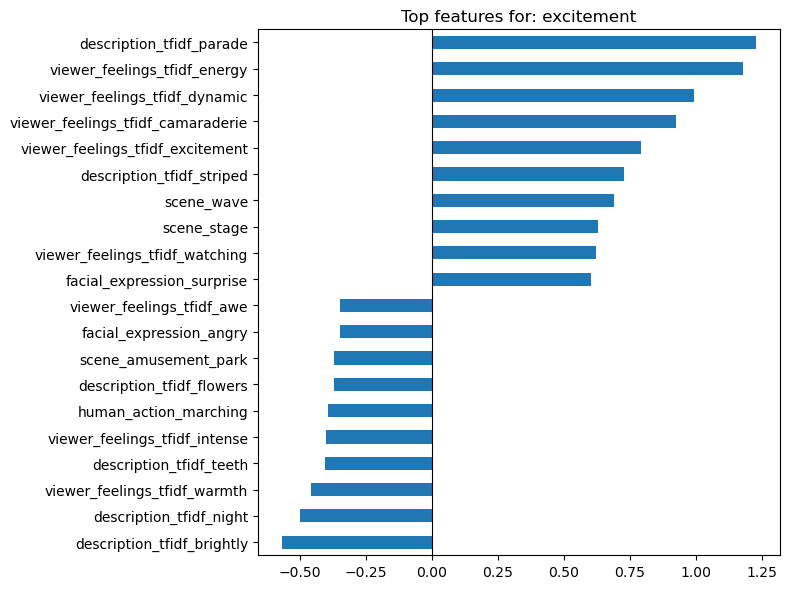

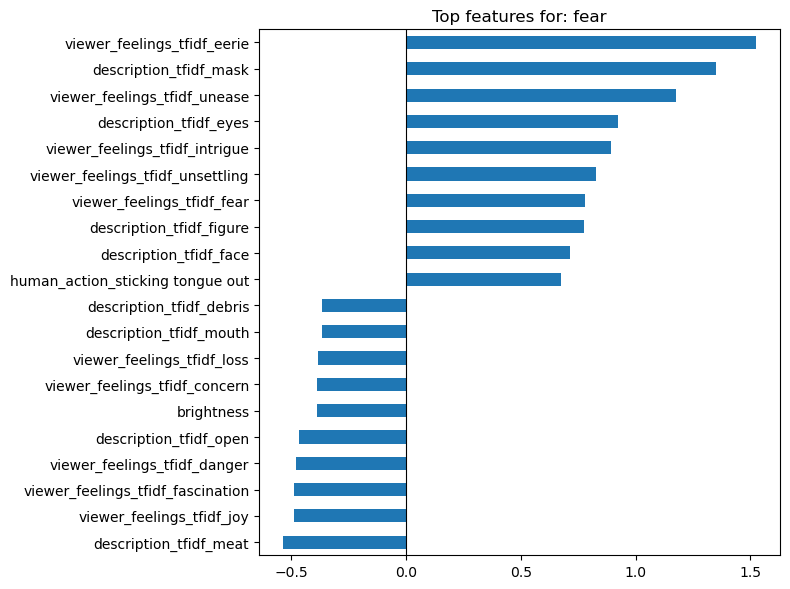

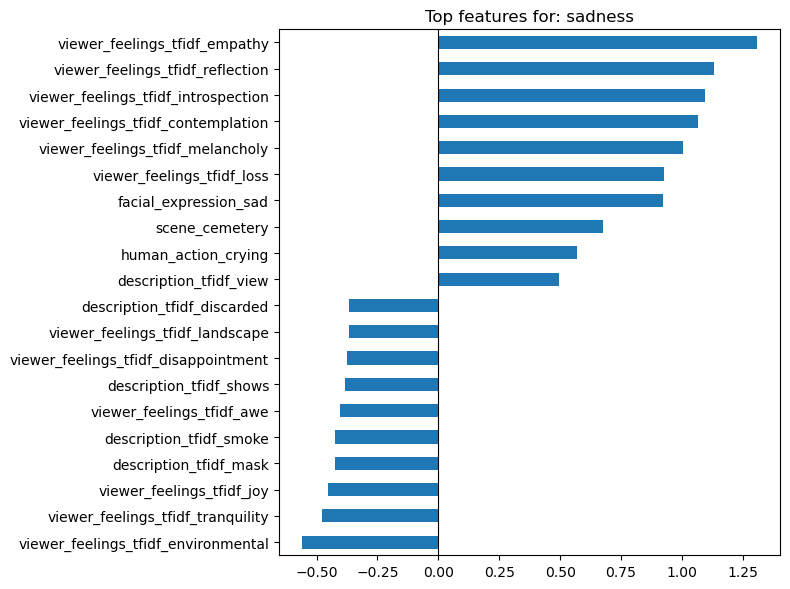

In [65]:
#TODO - interpret model, feature importance


coef_df = pd.DataFrame(best_clf.coef_, index=best_clf.classes_, columns=feature_names)

def plot_top_features(emotion, n=10):
    coefs = coef_df.loc[emotion].sort_values()
    top = pd.concat([coefs.head(n), coefs.tail(n)])
    top.plot(kind='barh', figsize=(8, 6))
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Top features for: {emotion}')
    plt.tight_layout()
    plt.show()

for emotion in best_clf.classes_:
    plot_top_features(emotion)

149

,Mean,Sum
Description TF-IDF,0.225966,108.463478
Feelings TF-IDF,0.259370,124.497619
brightness,0.162599,1.300795
colorfulness,0.160770,1.286161
scene,0.116635,11.196968
human_action,0.156846,10.038159
facial_expression,0.173903,8.347332


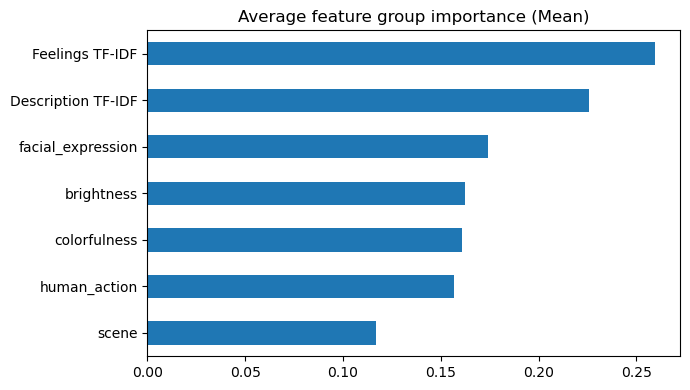

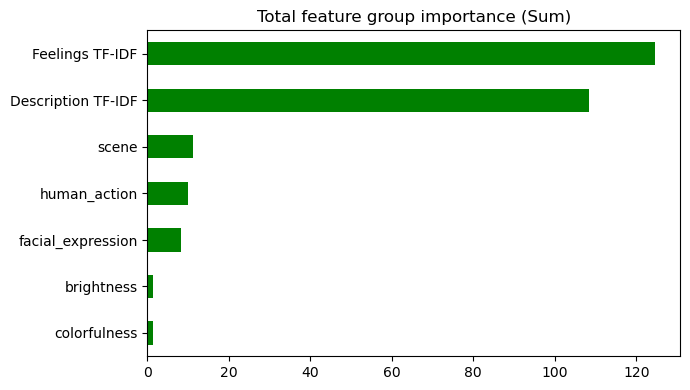

,Description TF-IDF,Feelings TF-IDF,brightness,colorfulness,scene,human_action,facial_expression
amusement,0.263137,0.244878,0.342482,0.372426,0.121796,0.176138,0.062676
anger,0.224721,0.249487,0.093353,0.110946,0.078269,0.278980,0.420018
awe,0.263885,0.255196,0.005280,0.152701,0.103714,0.119169,0.039460
contentment,0.227674,0.251526,0.209341,0.071153,0.085700,0.070597,0.110263
disgust,0.215732,0.283488,0.098045,0.092816,0.080535,0.091990,0.127603
excitement,0.213393,0.230532,0.028198,0.025073,0.245965,0.206442,0.257516
fear,0.216509,0.270264,0.389096,0.157619,0.099871,0.169092,0.066852
sadness,0.182674,0.289590,0.134998,0.303426,0.117229,0.142362,0.306835


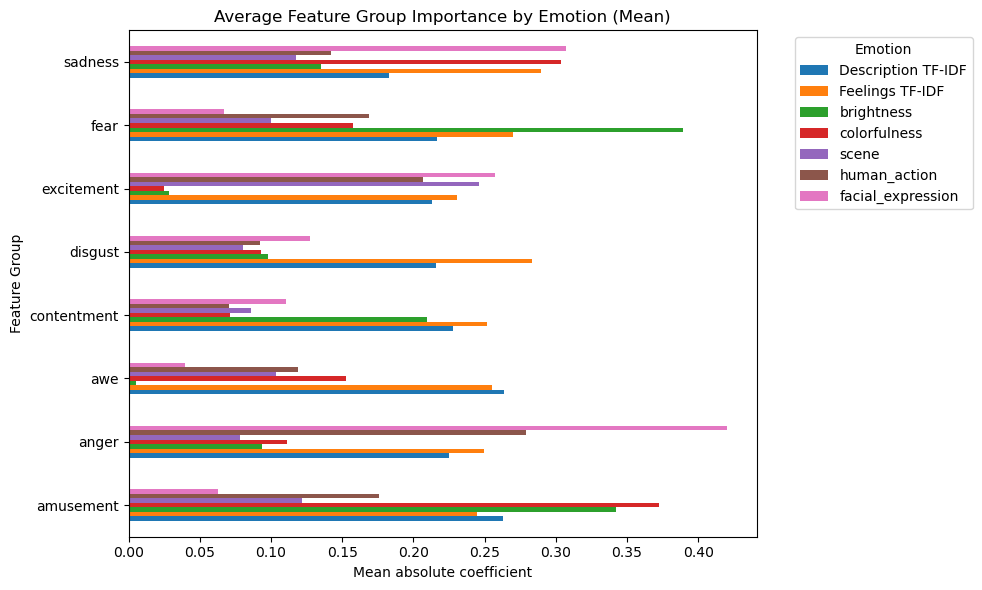

,Description TF-IDF,Feelings TF-IDF,brightness,colorfulness,scene,human_action,facial_expression
amusement,15.788235,14.692695,0.342482,0.372426,1.461557,1.409103,0.376054
anger,13.483271,14.969192,0.093353,0.110946,0.939232,2.231838,2.520105
awe,15.833072,15.311744,0.005280,0.152701,1.244571,0.953351,0.236761
contentment,13.660425,15.091576,0.209341,0.071153,1.028399,0.564773,0.661579
disgust,12.943911,17.009262,0.098045,0.092816,0.966424,0.735920,0.765619
excitement,12.803590,13.831903,0.028198,0.025073,2.951582,1.651539,1.545094
fear,12.990558,16.215839,0.389096,0.157619,1.198453,1.352736,0.401112
sadness,10.960415,17.375409,0.134998,0.303426,1.406751,1.138899,1.841007


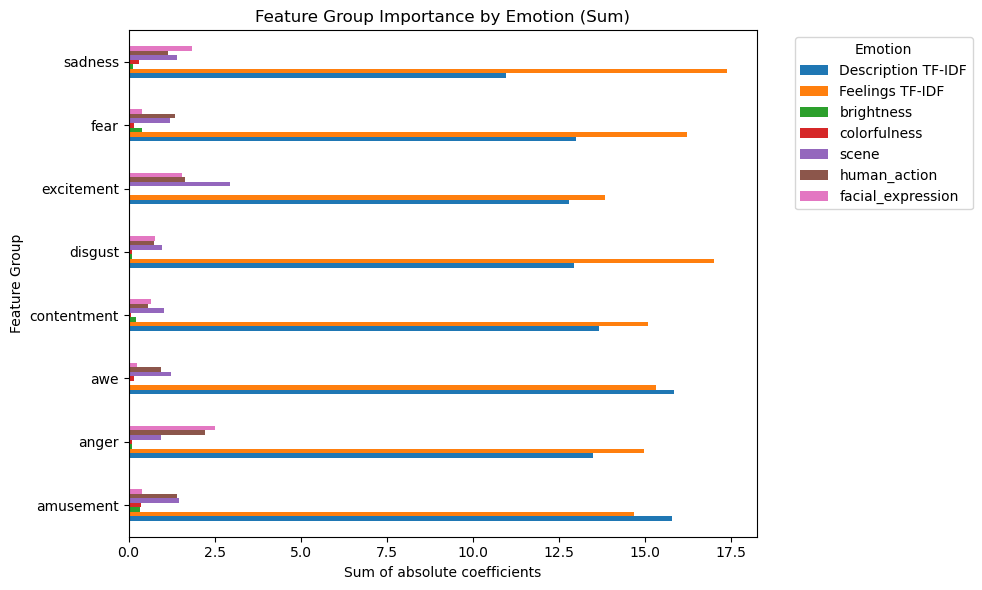

In [66]:
# Define your feature group slices (adjust indices to match your feature order)
num_features = len(feature_names)
display(num_features)

abs_coef = np.abs(best_clf.coef_)  
def get_indices(metadata_column_names):
    return [
        i for i, fname in enumerate(feature_names)
        if any(fname.startswith(cat) for cat in metadata_column_names)
    ]

groups = {
    # Get the indices where "brightness" and "colorfulness" are in feature_names
    #'Numeric (brightness, colorfulness)': get_indices(NUMERIC_METADATA),
    # 'Categorical (OHE)': get_indices(CATEGORICAL_METADATA),
    'Description TF-IDF': get_indices(['description']),
    'Feelings TF-IDF': get_indices(['viewer_feelings']),
    'brightness': get_indices(['brightness']),
    'colorfulness': get_indices(['colorfulness']),
    'scene': get_indices(['scene']),
    'human_action': get_indices(['human_action']),
    'facial_expression': get_indices(['facial_expression'])
}

# Show mean and sum for each group across all classes
group_stats = {
    name: {
        'mean': abs_coef[:, idxs].mean(),
        'sum': abs_coef[:, idxs].sum()
    }
    for name, idxs in groups.items()
}

group_importance_mean = {name: stats['mean'] for name, stats in group_stats.items()}
group_importance_sum = {name: stats['sum'] for name, stats in group_stats.items()}

df_group_summary = pd.DataFrame({
    'Mean': pd.Series(group_importance_mean),
    'Sum': pd.Series(group_importance_sum)
})

display(df_group_summary)

df_group_summary['Mean'].sort_values().plot(kind='barh', figsize=(7, 4), label='Mean')
plt.title('Average feature group importance (Mean)')
plt.tight_layout()
plt.show()

df_group_summary['Sum'].sort_values().plot(kind='barh', figsize=(7, 4), color='green', label='Sum')
plt.title('Total feature group importance (Sum)')
plt.tight_layout()
plt.show()

# Plot average and sum feature group importance by emotion
group_importance_by_emotion_mean = pd.DataFrame({
    group: abs_coef[:, idxs].mean(axis=1)
    for group, idxs in groups.items()
}, index=best_clf.classes_)

group_importance_by_emotion_sum = pd.DataFrame({
    group: abs_coef[:, idxs].sum(axis=1)
    for group, idxs in groups.items()
}, index=best_clf.classes_)

display(group_importance_by_emotion_mean)
fig, ax = plt.subplots(figsize=(10, 6))
group_importance_by_emotion_mean.plot.barh(ax=ax)
plt.title('Average Feature Group Importance by Emotion (Mean)')
plt.xlabel('Mean absolute coefficient')
plt.ylabel('Feature Group')
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(group_importance_by_emotion_sum)
fig, ax = plt.subplots(figsize=(10, 6))
group_importance_by_emotion_sum.plot.barh(ax=ax)
plt.title('Feature Group Importance by Emotion (Sum)')
plt.xlabel('Sum of absolute coefficients')
plt.ylabel('Feature Group')
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

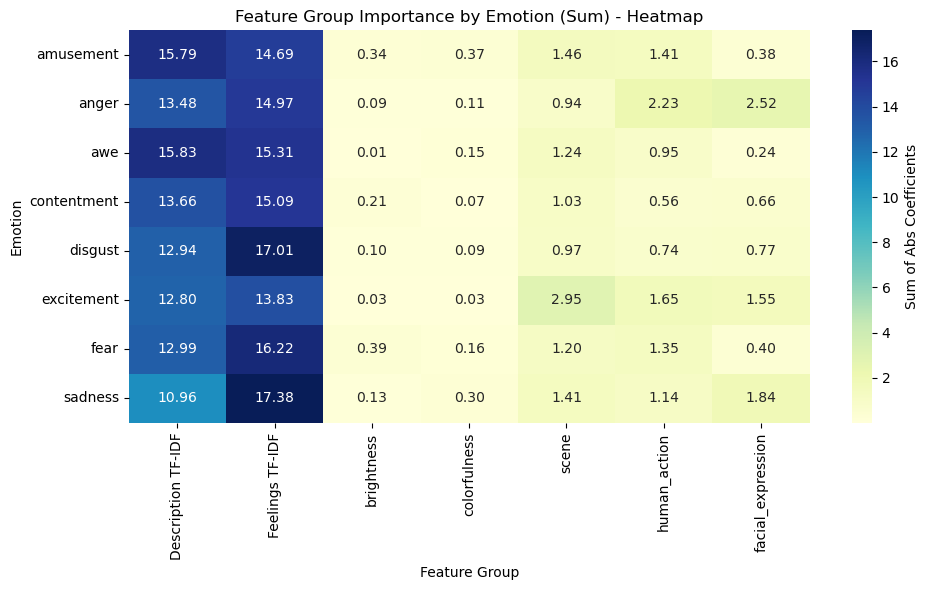

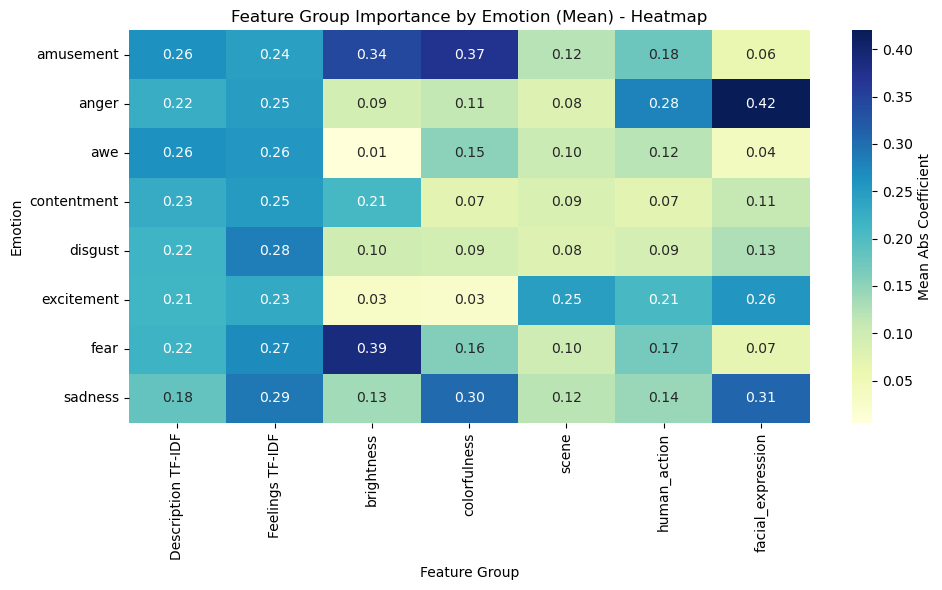

In [67]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(group_importance_by_emotion_sum, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Sum of Abs Coefficients'})
plt.title('Feature Group Importance by Emotion (Sum) - Heatmap')
plt.xlabel('Feature Group')
plt.ylabel('Emotion')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(group_importance_by_emotion_mean, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Mean Abs Coefficient'})
plt.title('Feature Group Importance by Emotion (Mean) - Heatmap')
plt.xlabel('Feature Group')
plt.ylabel('Emotion')
plt.tight_layout()
plt.show()

In [68]:
# PART 2: Using embeddings

## Part 2.1: Create X so it contains all embeddings, and Y is the emotion column
embeddings_stacked = [np.vstack(df[col].values) for col in EMBEDDING_COLUMNS]
X = np.hstack(embeddings_stacked)

y = df['emotion']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

display(X_train.shape)

(780, 3584)

Number of features: 3584; Number of samples: 780


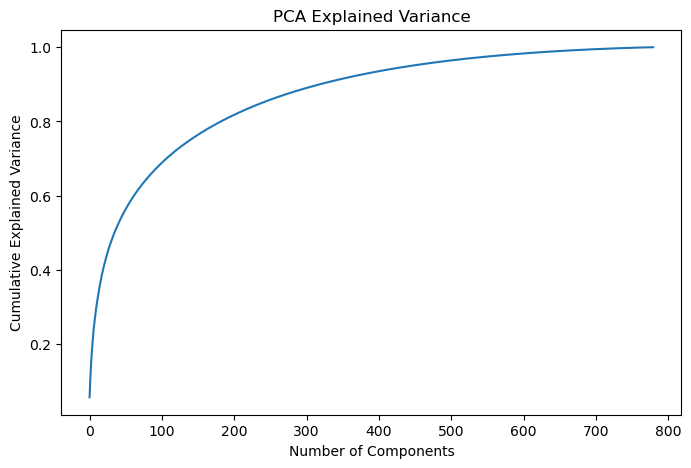

,Cumulative Variance Ratio,Explained Variance Ratio
0,0.056629,0.056629
50,0.564122,0.003494
100,0.688812,0.001863
150,0.764369,0.001256
200,0.818035,0.000929
250,0.858771,0.000714
300,0.890328,0.000557
350,0.915389,0.000449
400,0.935460,0.000359
450,0.951590,0.000290


In [69]:
# Conduct PCA 
print(f"Number of features: {X_train.shape[1]}; Number of samples: {X_train.shape[0]}")
max_n_components = min(X_train.shape[1], X_train.shape[0])
pca_test = PCA(n_components=max_n_components)
pca_test.fit(X_train)

explained_variance = pca_test.explained_variance_ratio_
cumulative_variance = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

pca_df = pd.DataFrame()
pca_df['Cumulative Variance Ratio'] = cumulative_variance
pca_df['Explained Variance Ratio'] = explained_variance
display(pca_df.iloc[::50].head(20))

In [ ]:
# Train on several classifiers, ultimately picking the best one 
classifiers = [ 
    RandomForestClassifier(random_state=42),
    GradientBoostingClassifier(random_state=42),
    MLPClassifier(random_state=42, max_iter=1000),
    LogisticRegression(solver='lbfgs', max_iter=200)
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_cv_score = 0
best_clf = None
best_n = None
best_pca = None

for clf in classifiers:
    for n in [50, 100, 150, 200, 250]:
        pca = PCA(n_components=n)
        pca.fit(X_train)
        X_train_pca = pca.transform(X_train)
        scores = cross_val_score(clf, X_train_pca, y_train, cv=cv, scoring='accuracy')
        print(f"{clf.__class__.__name__} n={n}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

        if scores.mean() > best_cv_score:
            best_cv_score = scores.mean()
            best_clf = copy.deepcopy(clf)
            best_n = n
            best_name = clf.__class__.__name__
            best_pca = pca

# Refit best on full train, evaluate once on test
X_train_pca = best_pca.transform(X_train)
X_test_pca = best_pca.transform(X_test)
best_clf.fit(X_train_pca, y_train)
y_pred = best_clf.predict(X_test_pca)
print(f"\nBest: {best_name} n={best_n} CV={best_cv_score*100:.2f}%")
print(f"Test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred))

RandomForestClassifier n=50: 70.77% ± 4.69%
RandomForestClassifier n=100: 71.03% ± 4.10%
RandomForestClassifier n=150: 71.28% ± 4.04%
RandomForestClassifier n=200: 69.36% ± 4.72%
RandomForestClassifier n=250: 67.56% ± 4.45%
GradientBoostingClassifier n=50: 67.05% ± 4.53%
GradientBoostingClassifier n=100: 65.77% ± 4.84%
